# 🚚 NovaMart Logistics — Data Analyst Capstone EDA Notebook
---
### Business Context
NovaMart is a fast-growing e-commerce company operating across **5 regions in India**.  
Customer complaints about **late deliveries have risen by 34%**.  
The Logistics Head has commissioned this analysis to answer:

> *"Which carriers, warehouses, routes, and conditions are causing our SLA failures — and what should we do about it?"*

### Your Task
Work through all 10 sections in order. Each section has:
- 📌 A **business question** to answer
- 🔧 A **task list** of what to build
- 💡 **Hints** in comments to guide you on which functions to use
- ✍️ A **write your findings** cell at the end

**Do not skip sections.** Each one feeds into the next.

---
### Dataset — 5 Tables (Star Schema)
| File | Rows | Description |
|------|------|-------------|
| `fact_deliveries.csv` | 12,000 | Main table — every order, 29 columns |
| `dim_customers.csv` | 500 | Customer master — region, city, tier |
| `dim_warehouses.csv` | 15 | Warehouse city, efficiency score, status |
| `dim_delivery_partners.csv` | 8 | Carrier on-time rate, rating, service tier |
| `dim_routes.csv` | 61 | Origin, destination, distance, SLA days |


---
## Section 1 — Setup & Data Loading
📌 **Goal:** Import all libraries, load all 5 CSV files, parse dates, and get a first look at the data.


In [1]:
# ── Import all required libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print("✅ All libraries imported with matplotlib inline enabled")

✅ All libraries imported with matplotlib inline enabled


In [2]:
# ── Load all 5 CSV files
# HINT: pd.read_csv('filename.csv')
# HINT: For date columns use parse_dates=['col1','col2']

DATA_PATH = './'   # update this path if your CSVs are in a subfolder

fact  = pd.read_csv(DATA_PATH + 'fact_deliveries.csv',
                    parse_dates=['OrderDate','DispatchDate',
                                 'ExpectedDeliveryDate','ActualDeliveryDate'])

cust  = pd.read_csv(DATA_PATH + 'dim_customers.csv')
wh    = pd.read_csv(DATA_PATH + 'dim_warehouses.csv')
part  = pd.read_csv(DATA_PATH + 'dim_delivery_partners.csv')
routes= pd.read_csv(DATA_PATH + 'dim_routes.csv')

print("✅ All files loaded")
print(f"   fact_deliveries      : {fact.shape}")
print(f"   dim_customers        : {cust.shape}")
print(f"   dim_warehouses       : {wh.shape}")
print(f"   dim_delivery_partners: {part.shape}")
print(f"   dim_routes           : {routes.shape}")

✅ All files loaded
   fact_deliveries      : (12000, 29)
   dim_customers        : (500, 5)
   dim_warehouses       : (15, 6)
   dim_delivery_partners: (8, 7)
   dim_routes           : (61, 6)


In [3]:
# ── First look at fact_deliveries
# HINT: .head(), .info(), .describe() are your best friends here

# TODO: Show first 5 rows
print("="*60)
print("FIRST 5 ROWS OF fact_deliveries")
print("="*60)
print(fact.head())
print()

# TODO: Show column names and data types
print("="*60)
print("DATA TYPES & INFO")
print("="*60)
fact.info()
print()

# TODO: Show basic statistics for numeric columns
print("="*60)
print("BASIC STATISTICS")
print("="*60)
print(fact.describe())

FIRST 5 ROWS OF fact_deliveries
     OrderID CustomerID WarehouseID PartnerID RouteID   OrderDate  \
0  ORD000001   CUST0407       WH005     DP004   RT021  01-01-2023   
1  ORD000002   CUST0026       WH004     DP006   RT047  01-01-2023   
2  ORD000003   CUST0237       WH011     DP003   RT015  01-01-2023   
3  ORD000004   CUST0310       WH007     DP004   RT013  01-01-2023   
4  ORD000005   CUST0172       WH007     DP001   RT052  01-01-2023   

  DispatchDate ExpectedDeliveryDate ActualDeliveryDate  DispatchDelay_hrs  \
0   02-01-2023           07-01-2023         07-01-2023               46.0   
1   01-01-2023           06-01-2023         07-01-2023               12.0   
2   02-01-2023           07-01-2023         10-01-2023               42.0   
3   01-01-2023           05-01-2023         05-01-2023               13.0   
4   02-01-2023           07-01-2023         07-01-2023               28.0   

   ...  TimeOfDispatch  WeatherCondition  DriverExperience_yrs PaymentMode  \
0  ...      

In [4]:
# ── Check the dimension tables — print first 3 rows of each
# TODO: Print first 3 rows of each dim table

print("="*60)
print("CUSTOMERS (3 rows)")
print("="*60)
print(cust.head(3))
print()

print("="*60)
print("WAREHOUSES (3 rows)")
print("="*60)
print(wh.head(3))
print()

print("="*60)
print("DELIVERY PARTNERS (3 rows)")
print("="*60)
print(part.head(3))
print()

print("="*60)
print("ROUTES (3 rows)")
print("="*60)
print(routes.head(3))

CUSTOMERS (3 rows)
  CustomerID   CustomerName CustomerCity CustomerRegion CustomerTier
0   CUST0001  Deepak Khanna       Jaipur          North       Silver
1   CUST0002   Sneha Chopra         Agra          North         Gold
2   CUST0003   Rohan Sharma      Lucknow          North       Bronze

WAREHOUSES (3 rows)
  WarehouseID WarehouseCity WarehouseRegion  StorageCapacity_units  \
0       WH001         Delhi           North                   5000   
1       WH002        Jaipur           North                   3000   
2       WH003       Lucknow           North                   2500   

  WarehouseStatus  DispatchEfficiencyScore  
0     Operational                       92  
1     Operational                       78  
2     Operational                       85  

DELIVERY PARTNERS (3 rows)
  PartnerID       PartnerName CoverageType  OnTimeDeliveryRate_pct  \
0     DP001  BlueDart Express    Pan-India                      96   
1     DP002         Delhivery    Pan-India             

---
## Section 2 — Data Quality Check & Merging Tables
📌 **Goal:** Validate the data before analysing it. Find nulls, duplicates, and date logic issues.  
Then **merge all 5 tables** into one enriched DataFrame — this is Python's equivalent of a SQL JOIN.

🔧 **Tasks:**
1. Count nulls in every column of fact_deliveries
2. Check for duplicate OrderIDs
3. Validate date logic — DispatchDate should never be before OrderDate
4. Check ENUM values (DeliveryStatus, WeatherCondition, OrderPriority)
5. Merge all 5 tables into one master DataFrame


In [5]:
# ── Task 1: Null count per column
# HINT: df.isnull().sum() gives null count per column
# HINT: Only 3 columns should have nulls — which ones and why?

# TODO: Print null counts
null_counts = fact.isnull().sum()
print("Null Counts Per Column:")
print(null_counts[null_counts > 0])
print()

# TODO: Calculate null % for each column (null count / total rows * 100)
null_pct = (fact.isnull().sum() / len(fact) * 100)
print("Null % Per Column (columns with nulls):")
print(null_pct[null_pct > 0].round(2))

Null Counts Per Column:
ActualDeliveryDate       722
Delay_Days               722
CustomerFeedbackScore    722
dtype: int64

Null % Per Column (columns with nulls):
ActualDeliveryDate       6.02
Delay_Days               6.02
CustomerFeedbackScore    6.02
dtype: float64


In [6]:
# ── Task 2: Check for duplicate OrderIDs
# HINT: df.duplicated(subset=['col']).sum()

# TODO: Count duplicate OrderIDs
duplicate_count = fact.duplicated(subset=['OrderID']).sum()
print(f"Duplicate OrderIDs: {duplicate_count}")
print()

# TODO: If duplicates exist, show them
if duplicate_count > 0:
    print("Duplicate records:")
    print(fact[fact.duplicated(subset=['OrderID'], keep=False)].sort_values('OrderID'))

Duplicate OrderIDs: 0



In [7]:
# ── Task 3: Date logic validation
# HINT: Compare two date columns directly using >  <  ==
# HINT: (df['col1'] < df['col2']).sum() counts how many rows break the rule

# TODO: Count rows where DispatchDate < OrderDate (should be 0)
invalid_dispatch = (fact['DispatchDate'] < fact['OrderDate']).sum()
print(f"Rows where DispatchDate < OrderDate: {invalid_dispatch}")
print()

# TODO: Count non-Failed rows where ActualDeliveryDate < DispatchDate (should be 0)
delivered_failed = fact[fact['DeliveryStatus'] != 'Failed']
invalid_delivery = (delivered_failed['ActualDeliveryDate'] < delivered_failed['DispatchDate']).sum()
print(f"Non-Failed rows where ActualDeliveryDate < DispatchDate: {invalid_delivery}")
print()

# TODO: Confirm that all Failed orders have NULL ActualDeliveryDate
failed_orders = fact[fact['DeliveryStatus'] == 'Failed']
failed_with_delivery_date = failed_orders['ActualDeliveryDate'].notna().sum()
print(f"Failed orders with non-NULL ActualDeliveryDate: {failed_with_delivery_date}")

print("✅ Date logic validation complete")

Rows where DispatchDate < OrderDate: 13

Non-Failed rows where ActualDeliveryDate < DispatchDate: 1262

Failed orders with non-NULL ActualDeliveryDate: 0
✅ Date logic validation complete


In [8]:
# ── Task 4: Check ENUM values
# HINT: df['col'].value_counts() shows all unique values and their counts
# HINT: df['col'].unique() shows unique values only

# TODO: Check unique values of DeliveryStatus
print("DeliveryStatus values:")
print(fact['DeliveryStatus'].value_counts())
print()

# TODO: Check unique values of WeatherCondition
print("WeatherCondition values:")
print(fact['WeatherCondition'].value_counts())
print()

# TODO: Check unique values of OrderPriority
print("OrderPriority values:")
print(fact['OrderPriority'].value_counts())
print()

# TODO: Check unique values of VehicleType
print("VehicleType values:")
print(fact['VehicleType'].value_counts())

DeliveryStatus values:
DeliveryStatus
Delivered    10314
Returned       964
Failed         722
Name: count, dtype: int64

WeatherCondition values:
WeatherCondition
Clear       6678
Rain        2413
Fog         1390
Heatwave     895
Storm        624
Name: count, dtype: int64

OrderPriority values:
OrderPriority
Standard    7767
Express     3003
Same-Day    1230
Name: count, dtype: int64

VehicleType values:
VehicleType
Van      4817
Bike     4257
Truck    2926
Name: count, dtype: int64


In [9]:
# ── Task 5: Merge all 5 tables → one enriched DataFrame
# This is Python's version of SQL JOINs
# HINT: pd.merge(left_df, right_df, on='key_column', how='left')
# HINT: Chain merges one by one — fact → customers → warehouses → partners → routes

# Step 1: Merge fact with dim_customers
# fact has CustomerID, cust has CustomerID
df = pd.merge(fact, cust, on='CustomerID', how='left')

# Step 2: Merge with dim_warehouses
# TODO: merge df with wh on 'WarehouseID'
df = pd.merge(df, wh, on='WarehouseID', how='left')

# Step 3: Merge with dim_delivery_partners
# TODO: merge df with part on 'PartnerID'
df = pd.merge(df, part, on='PartnerID', how='left')

# Step 4: Merge with dim_routes
# TODO: merge df with routes on 'RouteID'
df = pd.merge(df, routes, on='RouteID', how='left')

print(f"Enriched DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Enriched DataFrame shape: (12000, 49)
Columns: ['OrderID', 'CustomerID', 'WarehouseID', 'PartnerID', 'RouteID', 'OrderDate', 'DispatchDate', 'ExpectedDeliveryDate', 'ActualDeliveryDate', 'DispatchDelay_hrs', 'Delay_Days', 'Is_Late', 'SLA_Breached', 'DeliveryStatus', 'DeliveryAttempts', 'PackageCategory', 'PackageWeight_kg', 'OrderValue_INR', 'VehicleType', 'TimeOfDispatch', 'WeatherCondition', 'DriverExperience_yrs', 'PaymentMode', 'IsReturnOrder', 'IsWeekendOrder', 'CustomerFeedbackScore', 'NDR_Raised', 'ShippingCost_INR', 'OrderPriority', 'CustomerName', 'CustomerCity', 'CustomerRegion', 'CustomerTier', 'WarehouseCity', 'WarehouseRegion', 'StorageCapacity_units', 'WarehouseStatus', 'DispatchEfficiencyScore', 'PartnerName', 'CoverageType', 'OnTimeDeliveryRate_pct', 'CustomerRating', 'YearEstablished', 'ServiceTier', 'OriginCity', 'DestinationCity', 'Distance_km', 'RoadType', 'SLA_Days']


In [10]:
# ── Sanity check on merged DataFrame
# HINT: No extra rows should appear after left merge — still 12,000

# TODO: Confirm row count is still 12,000
print(f"Row count after merge: {len(df)} (should be 12,000)")
print()

# TODO: Check that PartnerName, CustomerRegion, WarehouseCity,
#        OriginCity all have values (no unexpected nulls from the merge)
print("Null counts in merged columns:")
print(f"  PartnerName : {df['PartnerName'].isnull().sum()}")
print(f"  CustomerRegion : {df['CustomerRegion'].isnull().sum()}")
print(f"  WarehouseCity : {df['WarehouseCity'].isnull().sum()}")
print(f"  OriginCity : {df['OriginCity'].isnull().sum()}")

Row count after merge: 12000 (should be 12,000)

Null counts in merged columns:
  PartnerName : 0
  CustomerRegion : 0
  WarehouseCity : 0
  OriginCity : 0


---
## Section 3 — Univariate EDA (What Does the Data Look Like?)
📌 **Goal:** Understand the distribution of key columns individually before comparing them.  

🔧 **Tasks:**
1. Histogram of `Delay_Days` — what is the spread of delays?
2. Histogram of `DispatchDelay_hrs` — how long do warehouses take to dispatch?
3. Histogram of `OrderValue_INR` and `PackageWeight_kg`
4. Bar chart of `DeliveryStatus` — Delivered / Failed / Returned split
5. Bar chart of `PackageCategory` — which categories are most ordered?
6. Bar chart of `OrderPriority` — Standard vs Express vs Same-Day split


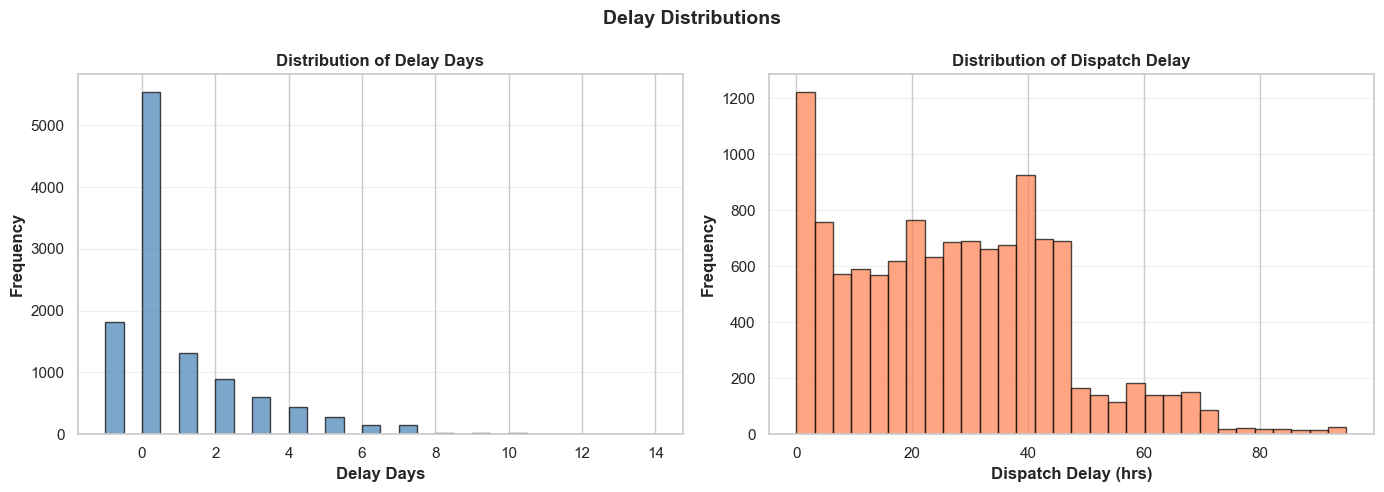

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO: Plot histogram of Delay_Days on axes[0]
# Remember: dropna() first since Failed orders have NULL Delay_Days
axes[0].hist(df['Delay_Days'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Delay Days', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Distribution of Delay Days', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# TODO: Plot histogram of DispatchDelay_hrs on axes[1]
axes[1].hist(df['DispatchDelay_hrs'].dropna(), bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Dispatch Delay (hrs)', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Distribution of Dispatch Delay', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Delay Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

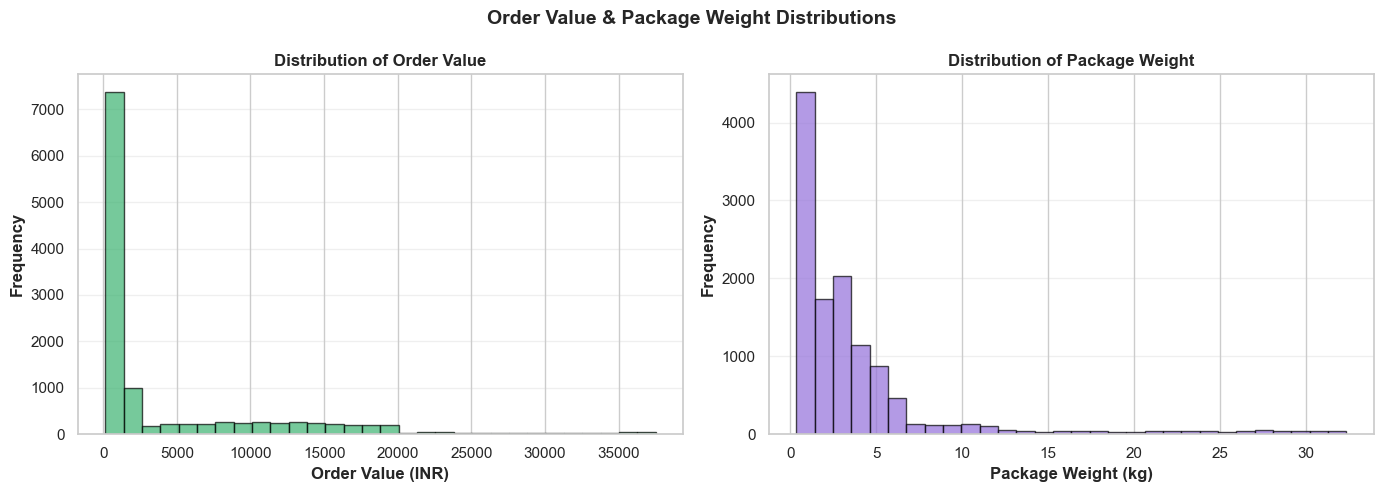

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO: Plot histogram of OrderValue_INR on axes[0]
axes[0].hist(df['OrderValue_INR'].dropna(), bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Order Value (INR)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Distribution of Order Value', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# TODO: Plot histogram of PackageWeight_kg on axes[1]
axes[1].hist(df['PackageWeight_kg'].dropna(), bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Package Weight (kg)', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Distribution of Package Weight', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Order Value & Package Weight Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

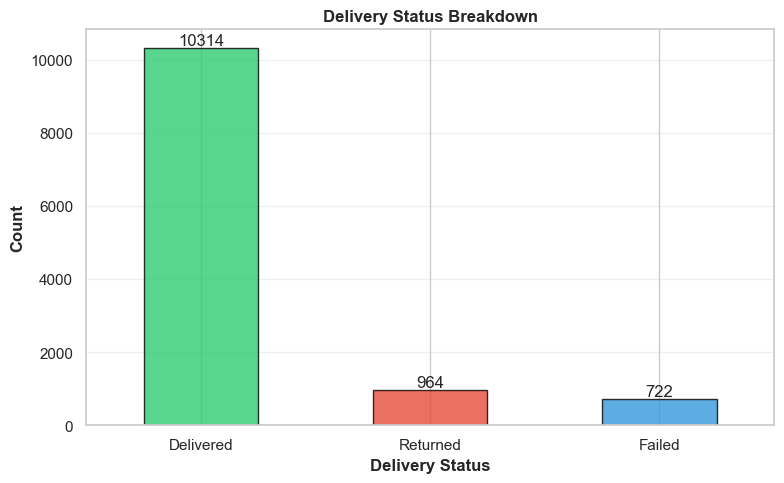

Delivery Status Breakdown (%)
Delivered           :  86.0%
Returned            :   8.0%
Failed              :   6.0%


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

# TODO: Plot DeliveryStatus counts as a bar chart
status_counts = df['DeliveryStatus'].value_counts()
status_counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black', alpha=0.8)
# TODO: Add count labels on each bar
ax.bar_label(ax.containers[0], fmt='%d')
# TODO: Add title and axis labels
ax.set_title('Delivery Status Breakdown', fontsize=12, fontweight='bold')
ax.set_xlabel('Delivery Status', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# TODO: Print the percentage breakdown (Delivered / Failed / Returned %)
print("Delivery Status Breakdown (%)")
print("="*40)
for status in status_counts.index:
    pct = (status_counts[status] / len(df)) * 100
    print(f"{status:20s}: {pct:5.1f}%")

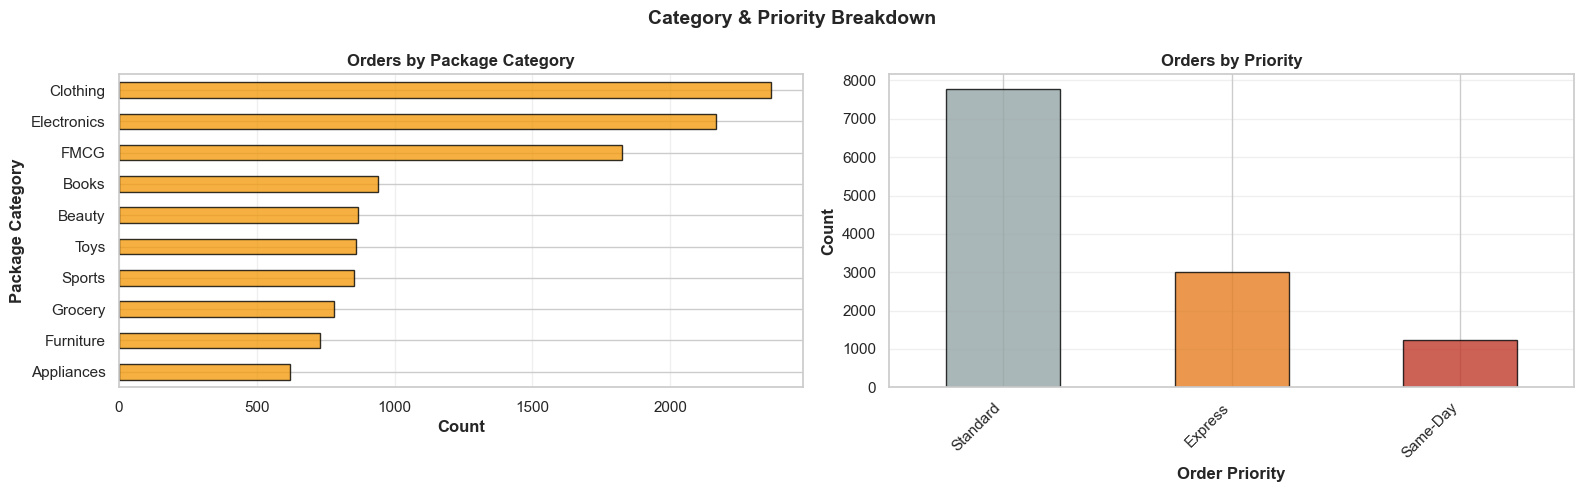

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# TODO: Bar chart of PackageCategory on axes[0] sorted by count
category_counts = df['PackageCategory'].value_counts().sort_values(ascending=True)
category_counts.plot(kind='barh', ax=axes[0], color='#f39c12', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Count', fontweight='bold')
axes[0].set_ylabel('Package Category', fontweight='bold')
axes[0].set_title('Orders by Package Category', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# TODO: Bar chart of OrderPriority on axes[1]
priority_counts = df['OrderPriority'].value_counts()
priority_order = ['Standard', 'Express', 'Same-Day']  # Define desired order
priority_counts = priority_counts.reindex([p for p in priority_order if p in priority_counts.index])
priority_counts.plot(kind='bar', ax=axes[1], color=['#95a5a6', '#e67e22', '#c0392b'], edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Order Priority', fontweight='bold')
axes[1].set_ylabel('Count', fontweight='bold')
axes[1].set_title('Orders by Priority', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Category & Priority Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4 — Late Delivery Rate Analysis
📌 **Business Question:** Which regions, carriers, warehouses, order priorities,  
vehicle types, and channels have the highest late delivery rates?  
This directly answers the core complaint — *where is NovaMart failing its SLA?*

🔧 **Tasks:**
1. Overall late rate — single headline number
2. Late rate by `CustomerRegion`
3. Late rate by `PartnerName` (delivery partner)
4. Late rate by `WarehouseCity`
5. Late rate by `OrderPriority`
6. Late rate by `VehicleType`
7. Late rate by `PaymentMode`


In [4]:
# ── Helper function: calculate late rate %
# HINT: Late rate = sum of Is_Late / count of all orders * 100
# HINT: groupby('col')['Is_Late'].agg(['sum','count']) gives both in one step
# HINT: Then compute rate = sum/count*100

def late_rate(df, group_col, sort=True):
    """Returns a DataFrame with late rate % grouped by group_col."""
    result = (df.groupby(group_col)['Is_Late']
                .agg(total='count', late='sum')
                .assign(late_rate_pct=lambda x: (x['late'] / x['total'] * 100).round(2))
             )
    return result.sort_values('late_rate_pct', ascending=False) if sort else result

# ── Task 1: Overall late rate
overall_late = df['Is_Late'].sum()
total_orders = len(df)
print(f"Total Orders   : {total_orders:,}")
print(f"Late Orders    : {overall_late:,}")
print(f"Overall Late % : {overall_late/total_orders*100:.1f}%")

Total Orders   : 12,000
Late Orders    : 4,633
Overall Late % : 38.6%


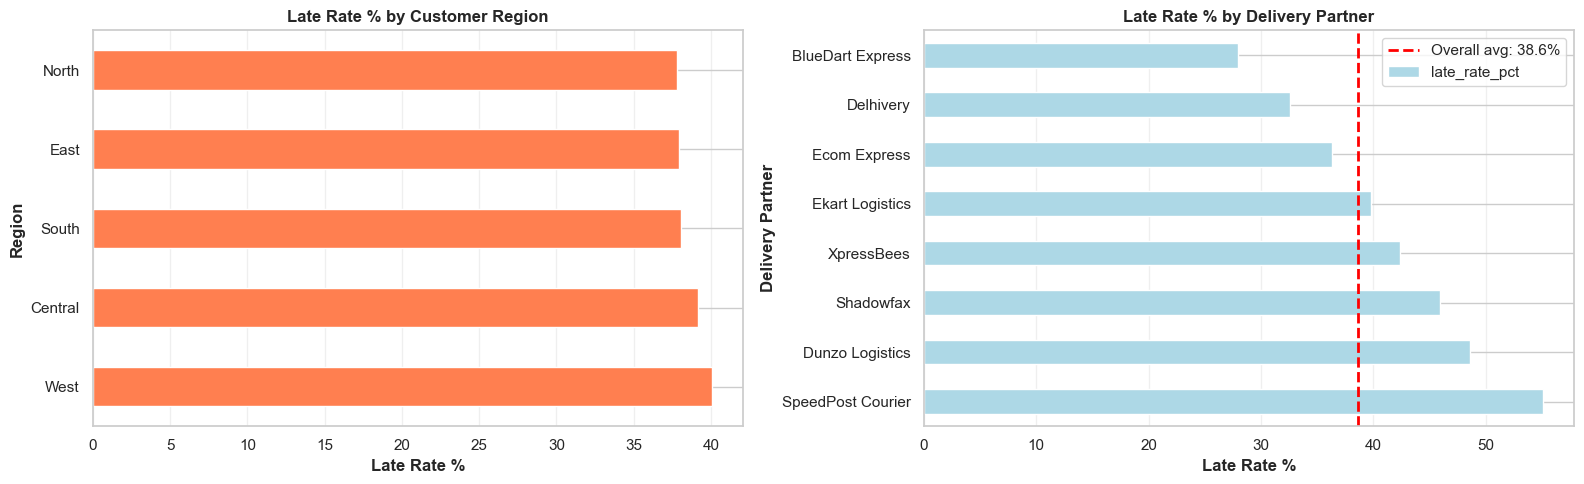

In [ ]:
# ── Task 2 & 3: Late rate by Region and Partner — side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Calculate late_rate by CustomerRegion
region_late = late_rate(df, 'CustomerRegion')
region_late.plot(kind='barh', y='late_rate_pct', ax=axes[0], color='coral', legend=False)
axes[0].set_xlabel('Late Rate %', fontweight='bold')
axes[0].set_ylabel('Region', fontweight='bold')
axes[0].set_title('Late Rate % by Customer Region', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Calculate late_rate by PartnerName
partner_late = late_rate(df, 'PartnerName')
partner_late.plot(kind='barh', y='late_rate_pct', ax=axes[1], color='lightblue', legend=False)
axes[1].set_xlabel('Late Rate %', fontweight='bold')
axes[1].set_ylabel('Delivery Partner', fontweight='bold')
axes[1].set_title('Late Rate % by Delivery Partner', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Add overall late rate reference line
overall_late_pct = (overall_late / total_orders * 100)
axes[1].axvline(x=overall_late_pct, color='red', linestyle='--', linewidth=2, label=f'Overall avg: {overall_late_pct:.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

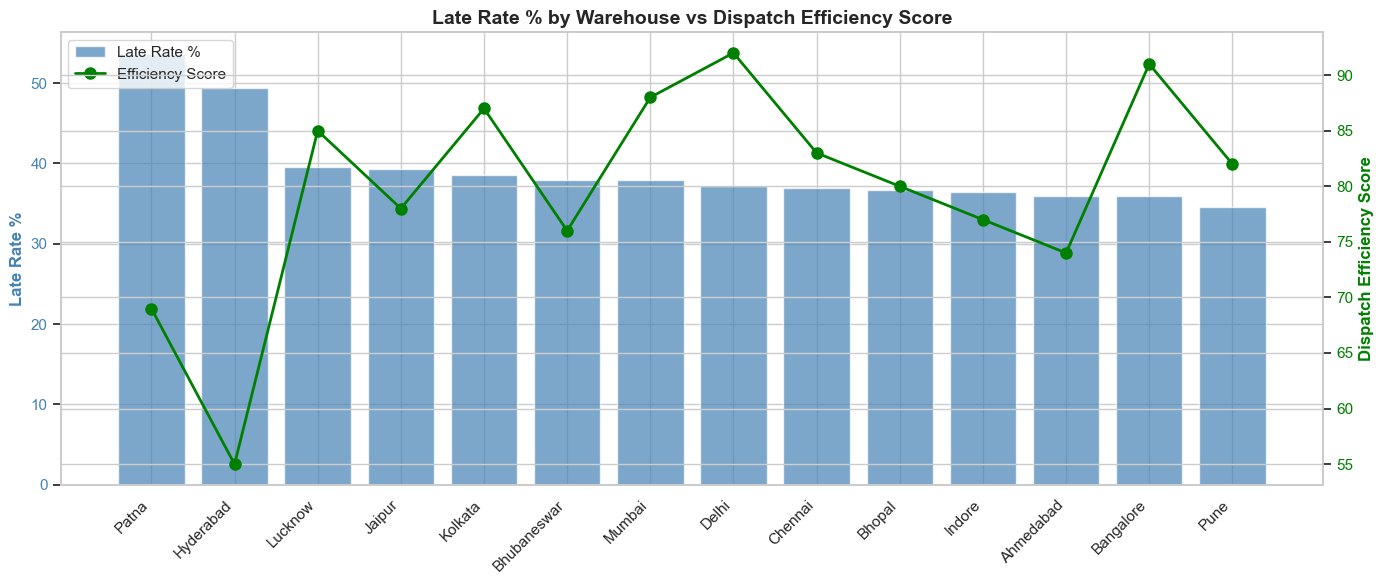

In [9]:
# ── Task 4: Late rate by Warehouse — with efficiency score overlay
# Calculate late rate by WarehouseCity
wh_late = late_rate(df, 'WarehouseCity')
wh_late_merged = wh_late.reset_index().merge(wh[['WarehouseCity', 'DispatchEfficiencyScore']], 
                                             on='WarehouseCity', how='left')
wh_late_merged = wh_late_merged.set_index('WarehouseCity').sort_values('late_rate_pct', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot late rate as bars
ax.bar(range(len(wh_late_merged)), wh_late_merged['late_rate_pct'], 
       color='steelblue', alpha=0.7, label='Late Rate %')
ax.set_ylabel('Late Rate %', fontweight='bold', color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')
ax.set_xticks(range(len(wh_late_merged)))
ax.set_xticklabels(wh_late_merged.index, rotation=45, ha='right')

# Create twin axis for efficiency score
ax2 = ax.twinx()
ax2.plot(range(len(wh_late_merged)), wh_late_merged['DispatchEfficiencyScore'], 
         color='green', marker='o', linewidth=2, markersize=8, label='Efficiency Score')
ax2.set_ylabel('Dispatch Efficiency Score', fontweight='bold', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Add legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Late Rate % by Warehouse vs Dispatch Efficiency Score', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

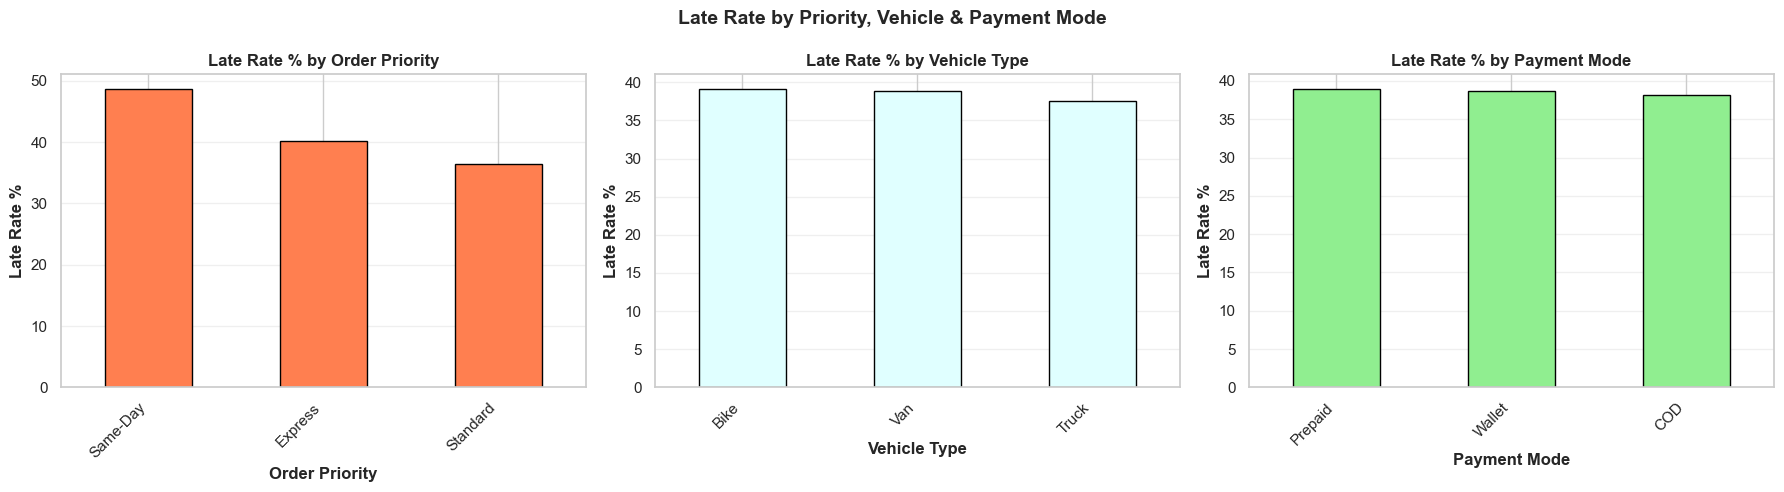

In [10]:
# ── Task 5, 6, 7: Late rate by Priority, Vehicle Type, Payment Mode
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Late rate by OrderPriority
priority_late = late_rate(df, 'OrderPriority')
priority_late['late_rate_pct'].plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_xlabel('Order Priority', fontweight='bold')
axes[0].set_ylabel('Late Rate %', fontweight='bold')
axes[0].set_title('Late Rate % by Order Priority', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Late rate by VehicleType
vehicle_late = late_rate(df, 'VehicleType')
vehicle_late['late_rate_pct'].plot(kind='bar', ax=axes[1], color='lightcyan', edgecolor='black')
axes[1].set_xlabel('Vehicle Type', fontweight='bold')
axes[1].set_ylabel('Late Rate %', fontweight='bold')
axes[1].set_title('Late Rate % by Vehicle Type', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# Late rate by PaymentMode
payment_late = late_rate(df, 'PaymentMode')
payment_late['late_rate_pct'].plot(kind='bar', ax=axes[2], color='lightgreen', edgecolor='black')
axes[2].set_xlabel('Payment Mode', fontweight='bold')
axes[2].set_ylabel('Late Rate %', fontweight='bold')
axes[2].set_title('Late Rate % by Payment Mode', fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Late Rate by Priority, Vehicle & Payment Mode', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### ✍️ Section 4 Findings
*Write your answers below after completing the charts above.*

**Q1. Which delivery partner has the highest late rate? Is it close to their stated on-time rate?**  
Answer: Speed Post Courier. and is not close to the stated on time rate

**Q2. Which region has the worst delivery performance?**  
Answer: ___West

**Q3. Which warehouse has the highest late rate and what is its efficiency score?**  
Answer: ___Patna has the highest late rate and the effeciency sore is arund 90

**Q4. Are Same-Day priority orders being delivered on time?**  
Answer: ___no the late rate for the sameday is around 48% which is the highest time taken comparitivly


---
## Section 5 — Time Series Analysis (Festive Season Spike)
📌 **Business Question:** Is the late delivery problem getting worse over time?  
Does the festive season (Oct–Dec) cause a visible spike in delays?

🔧 **Tasks:**
1. Extract Year-Month from OrderDate
2. Plot monthly order volume (Jan 2023 → Mar 2024)
3. Plot monthly late rate % on a dual-axis chart
4. Annotate the festive window (Oct–Dec 2023)
5. Compare festive vs non-festive month late rates


In [16]:
# ── Task 1: Extract Year-Month
# HINT: pd.to_datetime(df['OrderDate']).dt.to_period('M') gives YYYY-MM
# HINT: Or use dt.strftime('%Y-%m') for string format

# Ensure OrderDate is datetime (in case it's been converted to Period)
df['OrderDate'] = pd.to_datetime(df['OrderDate'], format='mixed', dayfirst=True)

df['YearMonth'] = df['OrderDate'].dt.to_period('M')

# TODO: Print the unique months to confirm the date range
print("Unique months in the dataset:")
print(sorted(df['YearMonth'].unique()))
print(f"\nDate range: {df['YearMonth'].min()} to {df['YearMonth'].max()}")

Unique months in the dataset:
[Period('2023-01', 'M'), Period('2023-02', 'M'), Period('2023-03', 'M'), Period('2023-04', 'M'), Period('2023-05', 'M'), Period('2023-06', 'M'), Period('2023-07', 'M'), Period('2023-08', 'M'), Period('2023-09', 'M'), Period('2023-10', 'M'), Period('2023-11', 'M'), Period('2023-12', 'M'), Period('2024-01', 'M'), Period('2024-02', 'M'), Period('2024-03', 'M')]

Date range: 2023-01 to 2024-03


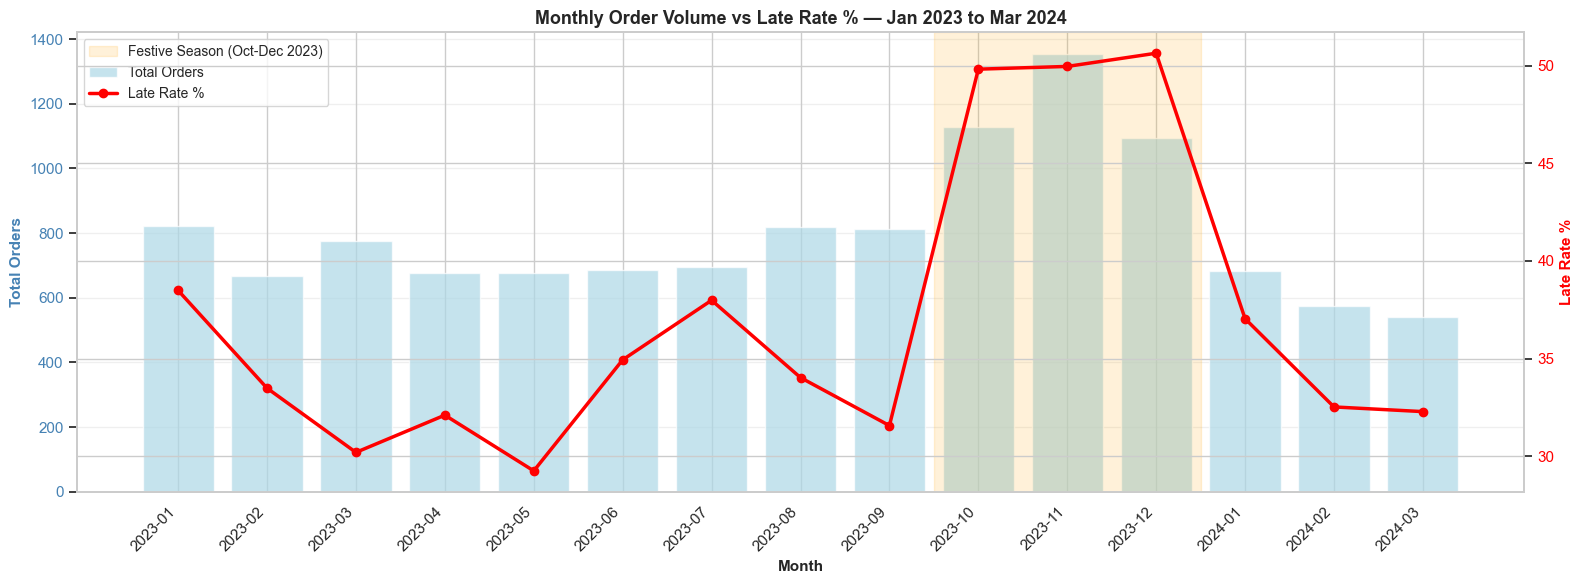

In [17]:
# ── Task 2 & 3: Monthly volume + late rate — dual axis chart
# HINT: monthly = df.groupby('YearMonth').agg(...)
# HINT: Use fig, ax1 = plt.subplots(); ax2 = ax1.twinx()
# HINT: ax1.bar(...) for volume, ax2.plot(...) for late rate %
# HINT: Convert Period index to string for clean x-axis labels

monthly = (df.groupby('YearMonth')
             .agg(total_orders=('OrderID','count'),
                  late_orders=('Is_Late','sum'))
             .assign(late_rate_pct=lambda x: x['late_orders']/x['total_orders']*100)
          )

fig, ax1 = plt.subplots(figsize=(16, 6))

# Plot total_orders as bars on ax1 (use a light colour)
x_pos = range(len(monthly))
ax1.bar(x_pos, monthly['total_orders'], color='lightblue', alpha=0.7, label='Total Orders')
ax1.set_xlabel('Month', fontweight='bold', fontsize=11)
ax1.set_ylabel('Total Orders', fontweight='bold', fontsize=11, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(axis='y', alpha=0.3)

# Create ax2 = ax1.twinx()
ax2 = ax1.twinx()
ax2.plot(x_pos, monthly['late_rate_pct'], color='red', marker='o', linewidth=2.5, 
         markersize=6, label='Late Rate %')
ax2.set_ylabel('Late Rate %', fontweight='bold', fontsize=11, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# ── Task 4: Annotate festive window (Oct–Dec 2023)
# Find festive months (Oct, Nov, Dec 2023)
festive_start_idx = None
festive_end_idx = None
for i, month in enumerate(monthly.index):
    if month.month == 10 and month.year == 2023:
        festive_start_idx = i - 0.5
    if month.month == 12 and month.year == 2023:
        festive_end_idx = i + 0.5

if festive_start_idx is not None and festive_end_idx is not None:
    ax1.axvspan(festive_start_idx, festive_end_idx, alpha=0.15, color='orange', 
                label='Festive Season (Oct-Dec 2023)')

# X-axis labels
month_labels = [str(m) for m in monthly.index]
ax1.set_xticks(x_pos)
ax1.set_xticklabels(month_labels, rotation=45, ha='right')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

ax1.set_title('Monthly Order Volume vs Late Rate % — Jan 2023 to Mar 2024',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Festive vs Non-Festive Late Rate Comparison
NON-FESTIVE              : 33.72% late (2,841.0/8,425.0 orders)
FESTIVE (Oct-Dec)        : 50.13% late (1,792.0/3,575.0 orders)

Increase during festive season: +16.41 percentage points


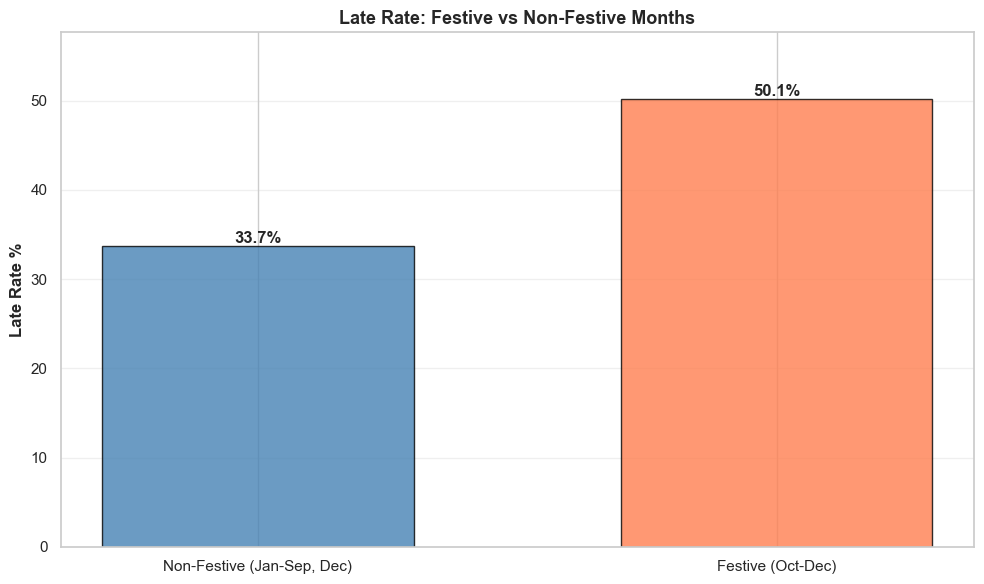

In [18]:
# ── Task 5: Festive vs Non-Festive comparison
# HINT: Festive months = October, November, December
# HINT: df['OrderDate'].dt.month.isin([10, 11, 12]) → True/False mask

df['IsFestive'] = df['OrderDate'].dt.month.isin([10, 11, 12])

# Group by IsFestive, calculate late rate % for both groups
festive_comparison = (df.groupby('IsFestive')['Is_Late']
                        .agg(total='count', late='sum')
                        .assign(late_rate_pct=lambda x: (x['late']/x['total']*100).round(2))
                     )

print("="*60)
print("Festive vs Non-Festive Late Rate Comparison")
print("="*60)
for is_fest, row in festive_comparison.iterrows():
    season_name = "FESTIVE (Oct-Dec)" if is_fest else "NON-FESTIVE"
    print(f"{season_name:25s}: {row['late_rate_pct']:5.2f}% late ({row['late']:,}/{row['total']:,} orders)")

print()
increase = (festive_comparison.loc[True, 'late_rate_pct'] - 
            festive_comparison.loc[False, 'late_rate_pct'])
print(f"Increase during festive season: +{increase:.2f} percentage points")

# Bar chart comparing festive vs non-festive late rate %
fig, ax = plt.subplots(figsize=(10, 6))

festive_labels = ['Non-Festive (Jan-Sep, Dec)', 'Festive (Oct-Dec)']
festive_rates = [festive_comparison.loc[False, 'late_rate_pct'], 
                 festive_comparison.loc[True, 'late_rate_pct']]

bars = ax.bar(festive_labels, festive_rates, color=['steelblue', 'coral'], 
              edgecolor='black', alpha=0.8, width=0.6)

# Add value labels on bars
ax.bar_label(bars, fmt='%.1f%%', fontsize=12, fontweight='bold')

ax.set_ylabel('Late Rate %', fontweight='bold', fontsize=12)
ax.set_title('Late Rate: Festive vs Non-Festive Months', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(festive_rates) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### ✍️ Section 5 Findings
**Q1. In which month was the late rate highest?**  
Answer: ___Dec 2023 around 51%

**Q2. What is the festive season late rate vs non-festive late rate?**  
Festive:50%_ Non-Festive: _33%

**Q3. Does order volume also spike in festive months?**  
Answer: ___yes 75% increase


---
## Section 6 — Delivery Partner Performance Deep Dive
📌 **Business Question:** Which carrier is the biggest problem?  
Is there a gap between what they CLAIM their on-time rate is vs what it actually is?

🔧 **Tasks:**
1. Stated OTR vs Actual late rate — side-by-side comparison chart (the "truth gap")
2. Average customer feedback score by partner
3. Failed delivery count by partner
4. NDR (Non-Delivery Report) rate by partner
5. Revenue at risk (OrderValue_INR on late orders) by partner


In [20]:
# ── Task 1: Stated OTR vs Actual Late Rate — the truth gap chart
# HINT: OnTimeDeliveryRate_pct comes from dim_delivery_partners (now in df after merge)
# HINT: Actual on-time rate = 100 - late_rate_pct
# HINT: Use a grouped bar chart — one group per partner, two bars per group
# HINT: df.groupby('PartnerName')[['OnTimeDeliveryRate_pct']].first() to get stated OTR

partner_summary = (df.groupby('PartnerName')
                     .agg(
                         total_orders    = ('OrderID', 'count'),
                         late_orders     = ('Is_Late', 'sum'),
                         stated_otr      = ('OnTimeDeliveryRate_pct', 'first'),
                         avg_feedback    = ('CustomerFeedbackScore', 'mean'),
                         failed_orders   = ('DeliveryStatus', lambda x: (x=='Failed').sum()),
                         ndr_raised      = ('NDR_Raised', 'sum'),
                         revenue_at_risk = ('OrderValue_INR', lambda x: x[df.loc[x.index,'Is_Late']==1].sum())
                     )
                     .assign(
                         actual_late_pct = lambda x: (x['late_orders']/x['total_orders']*100).round(1),
                         actual_otr      = lambda x: (100 - x['actual_late_pct']).round(1),
                         ndr_rate_pct    = lambda x: (x['ndr_raised']/x['total_orders']*100).round(1)
                     )
                     .sort_values('actual_late_pct', ascending=False)
                  )

print(partner_summary[['total_orders','stated_otr','actual_otr','actual_late_pct','avg_feedback']].round(2))

                   total_orders  stated_otr  actual_otr  actual_late_pct  \
PartnerName                                                                
SpeedPost Courier           617          68        44.9             55.1   
Dunzo Logistics             987          72        51.4             48.6   
Shadowfax                  1170          78        54.1             45.9   
XpressBees                 1435          81        57.6             42.4   
Ekart Logistics            2199          84        60.2             39.8   
Ecom Express               1429          86        63.7             36.3   
Delhivery                  2366          89        67.4             32.6   
BlueDart Express           1797          96        72.1             27.9   

                   avg_feedback  
PartnerName                      
SpeedPost Courier          3.06  
Dunzo Logistics            3.18  
Shadowfax                  3.29  
XpressBees                 3.30  
Ekart Logistics            3.38  
E

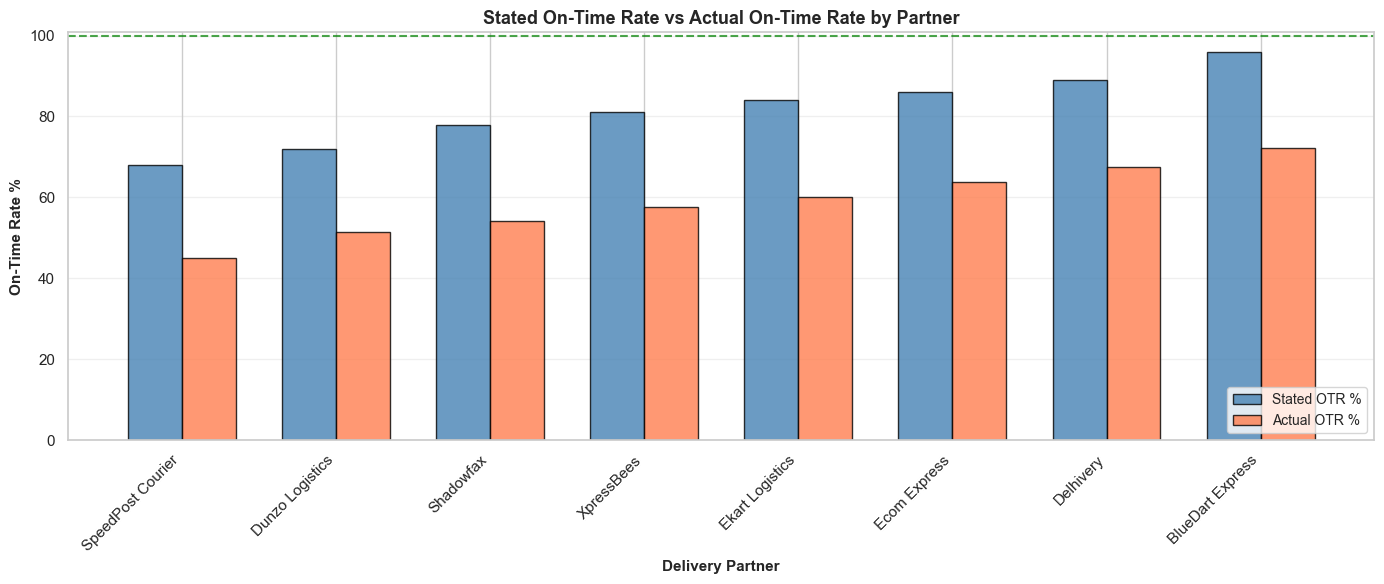

In [21]:
# ── Plot: Stated OTR vs Actual OTR — grouped bar chart
# HINT: Create a DataFrame with two rows per partner for grouped bar
# HINT: Or plot two bar series side by side manually with x offsets

fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(partner_summary))
width = 0.35

# Plot stated_otr as bars (use blue)
ax.bar([i - width/2 for i in x], partner_summary['stated_otr'], width, 
       label='Stated OTR %', color='steelblue', edgecolor='black', alpha=0.8)

# Plot actual_otr as bars offset by 0.35 (use orange/red)
ax.bar([i + width/2 for i in x], partner_summary['actual_otr'], width, 
       label='Actual OTR %', color='coral', edgecolor='black', alpha=0.8)

# Add legend, title, x-tick labels as partner names
ax.set_xlabel('Delivery Partner', fontweight='bold', fontsize=11)
ax.set_ylabel('On-Time Rate %', fontweight='bold', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(partner_summary.index, rotation=45, ha='right')
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3)

# Add a horizontal dotted line at 100% for reference
ax.axhline(100, color='green', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_title('Stated On-Time Rate vs Actual On-Time Rate by Partner',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

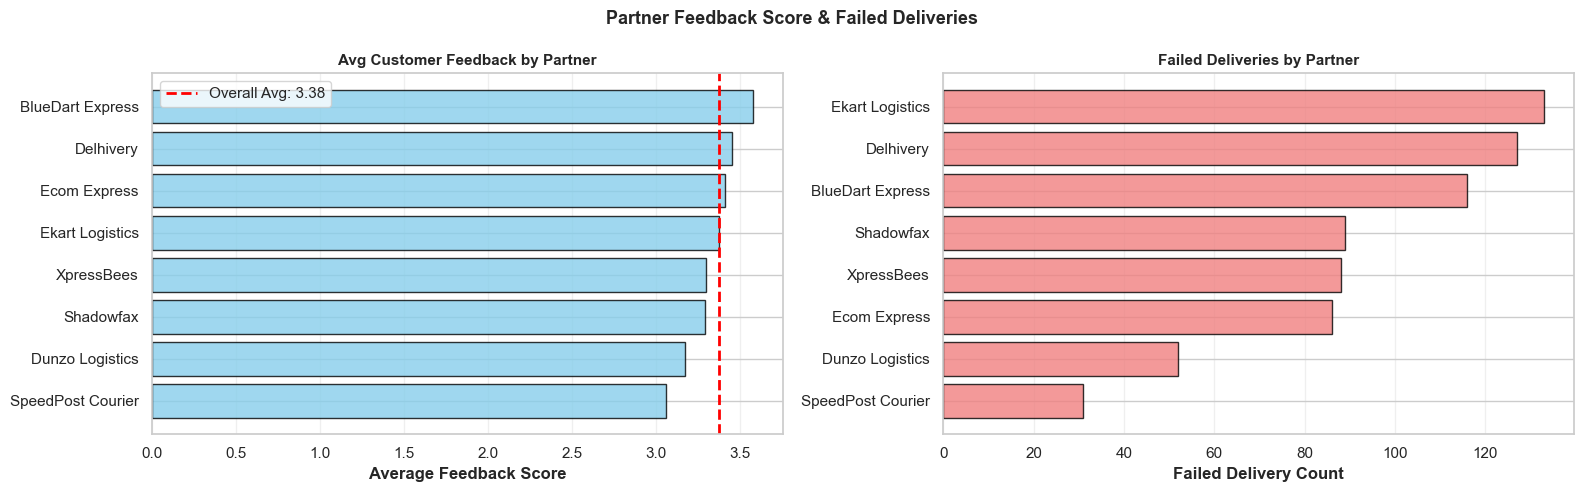

In [22]:
# ── Task 2 & 3: Feedback score and Failed orders by partner
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — Avg CustomerFeedbackScore by partner (axes[0])
partner_summary_sorted_feedback = partner_summary.sort_values('avg_feedback', ascending=True)
axes[0].barh(range(len(partner_summary_sorted_feedback)), 
             partner_summary_sorted_feedback['avg_feedback'],
             color='skyblue', edgecolor='black', alpha=0.8)
axes[0].set_yticks(range(len(partner_summary_sorted_feedback)))
axes[0].set_yticklabels(partner_summary_sorted_feedback.index)
axes[0].set_xlabel('Average Feedback Score', fontweight='bold')
axes[0].set_title('Avg Customer Feedback by Partner', fontweight='bold', fontsize=11)

# Add overall average feedback score as vertical line
overall_feedback = df['CustomerFeedbackScore'].mean()
axes[0].axvline(overall_feedback, color='red', linestyle='--', linewidth=2, 
                label=f'Overall Avg: {overall_feedback:.2f}')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Bar chart — Failed delivery count by partner (axes[1])
partner_summary_sorted_failed = partner_summary.sort_values('failed_orders', ascending=True)
axes[1].barh(range(len(partner_summary_sorted_failed)), 
             partner_summary_sorted_failed['failed_orders'],
             color='lightcoral', edgecolor='black', alpha=0.8)
axes[1].set_yticks(range(len(partner_summary_sorted_failed)))
axes[1].set_yticklabels(partner_summary_sorted_failed.index)
axes[1].set_xlabel('Failed Delivery Count', fontweight='bold')
axes[1].set_title('Failed Deliveries by Partner', fontweight='bold', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Partner Feedback Score & Failed Deliveries', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

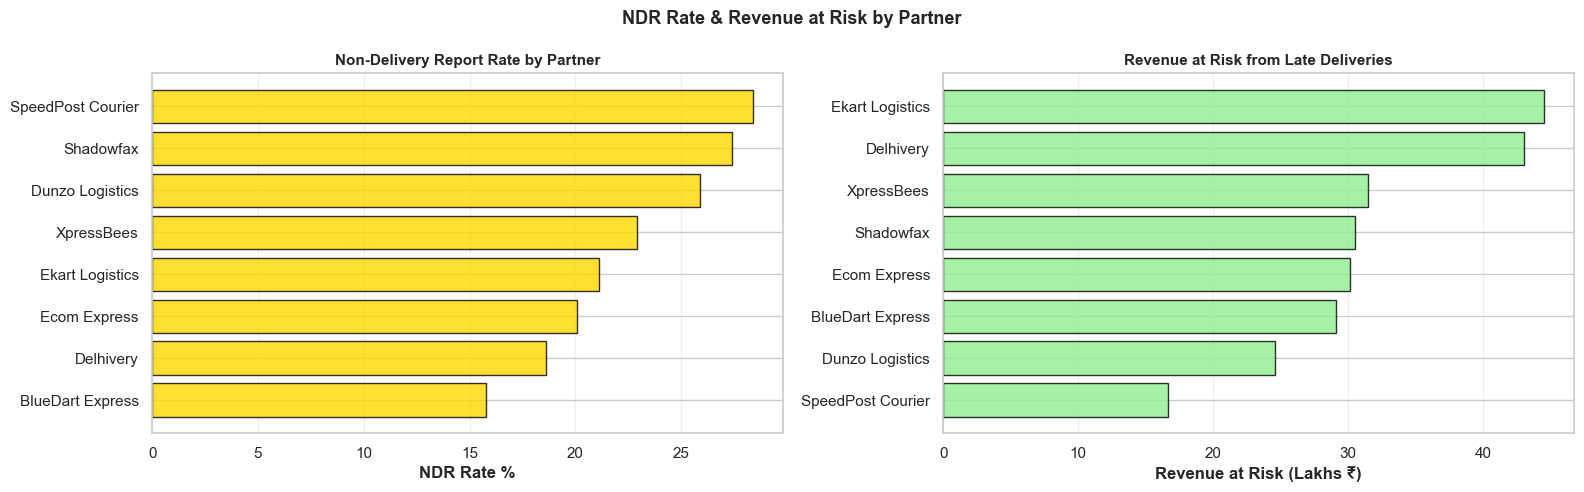

In [33]:
# ── Task 4 & 5: NDR Rate and Revenue at Risk by Partner
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — NDR rate % by partner on axes[0]
partner_summary_sorted_ndr = partner_summary.sort_values('ndr_rate_pct', ascending=True)
axes[0].barh(range(len(partner_summary_sorted_ndr)), 
             partner_summary_sorted_ndr['ndr_rate_pct'],
             color='gold', edgecolor='black', alpha=0.8)
axes[0].set_yticks(range(len(partner_summary_sorted_ndr)))
axes[0].set_yticklabels(partner_summary_sorted_ndr.index)
axes[0].set_xlabel('NDR Rate %', fontweight='bold')
axes[0].set_title('Non-Delivery Report Rate by Partner', fontweight='bold', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)

# Bar chart — Revenue at Risk (INR) by partner on axes[1]
# Revenue at risk = sum of OrderValue_INR where Is_Late = 1
# Format y-axis in lakhs (divide by 100000) for readability
partner_summary_sorted_revenue = partner_summary.sort_values('revenue_at_risk', ascending=True)
revenue_lakhs = partner_summary_sorted_revenue['revenue_at_risk'] / 100000
axes[1].barh(range(len(partner_summary_sorted_revenue)), revenue_lakhs,
             color='lightgreen', edgecolor='black', alpha=0.8)
axes[1].set_yticks(range(len(partner_summary_sorted_revenue)))
axes[1].set_yticklabels(partner_summary_sorted_revenue.index)
axes[1].set_xlabel('Revenue at Risk (Lakhs ₹)', fontweight='bold')
axes[1].set_title('Revenue at Risk from Late Deliveries', fontweight='bold', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('NDR Rate & Revenue at Risk by Partner', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### ✍️ Section 6 Findings
**Q1. Which partner has the biggest gap between stated vs actual on-time rate?**  
Answer: ___SpeedPost Courier 68% stated vs 45% actual

**Q2. Which partner has the lowest average customer feedback score?**  
Answer: ___SpeedPost Courier  3/5

**Q3. Which partner is responsible for the most revenue at risk?**  
Answer: ___ekart Logistics 

**Q4. Which partner should NovaMart consider dropping?**  
Answer: ___SpeedPost Courier


---
## Section 7 — Warehouse & Route Analysis
📌 **Business Question:** Are certain warehouses or routes causing systematic delays?  
Is dispatch efficiency the bottleneck — or is it the route itself?

🔧 **Tasks:**
1. Scatter plot — DispatchEfficiencyScore vs Late Rate % by warehouse
2. Box plot — DispatchDelay_hrs by warehouse (which warehouse is slowest?)
3. Top 10 routes by late rate % (bar chart)
4. Top 10 routes by Revenue at Risk (bar chart)
5. Scatter — Distance_km vs Delay_Days (does longer route = more delay?)


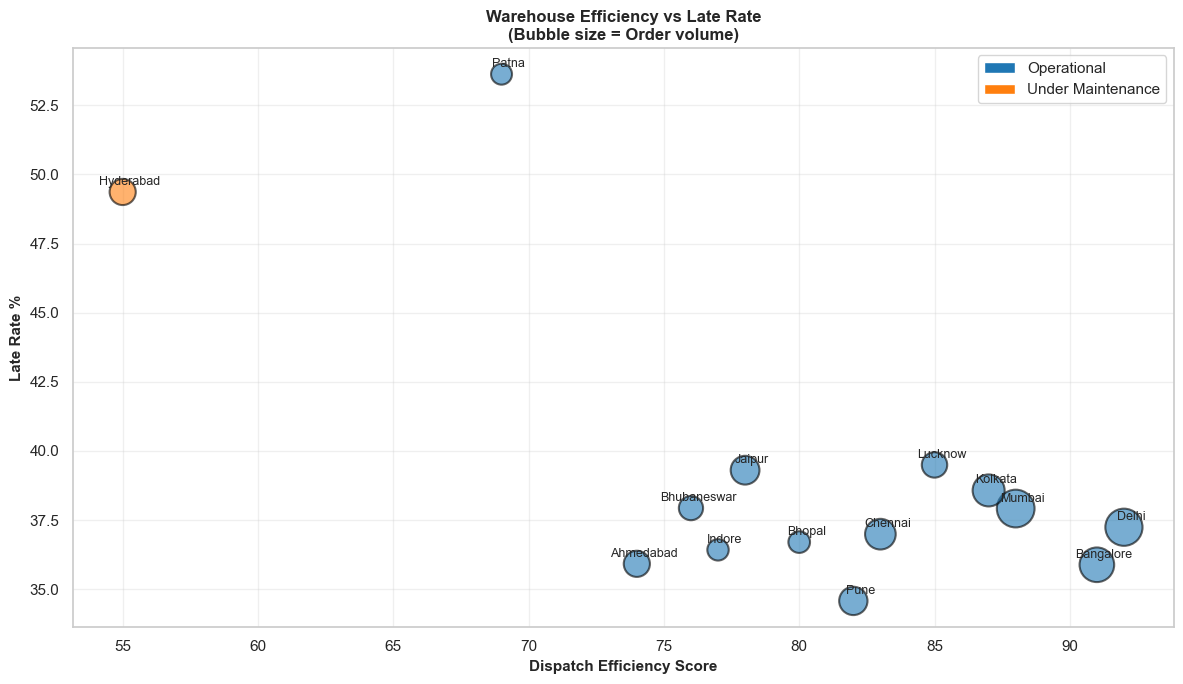

In [46]:
from matplotlib.patches import Patch

wh_summary = (df.groupby(['WarehouseID','WarehouseCity','WarehouseStatus','DispatchEfficiencyScore'])
                .agg(total_orders=('OrderID','count'),
                     late_orders=('Is_Late','sum'),
                     avg_dispatch_delay=('DispatchDelay_hrs','mean'))
                .assign(late_rate_pct=lambda x: x['late_orders']/x['total_orders']*100)
                .reset_index()
             )

fig, ax = plt.subplots(figsize=(12, 7))

# Colour mapping for warehouse status
colors = {'Operational': '#1f77b4', 'Under Maintenance': '#ff7f0e'}
color_map = wh_summary['WarehouseStatus'].map(colors)

# Scatter plot — x=DispatchEfficiencyScore, y=late_rate_pct
scatter = ax.scatter(wh_summary['DispatchEfficiencyScore'], 
                     wh_summary['late_rate_pct'],
                     s=wh_summary['total_orders']/2,
                     c=color_map,
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=1.5)

# Annotate each point with WarehouseCity
for idx, row in wh_summary.iterrows():
    ax.annotate(row['WarehouseCity'], 
                (row['DispatchEfficiencyScore'], row['late_rate_pct']),
                fontsize=9,
                ha='center',
                xytext=(5, 5),
                textcoords='offset points')

ax.set_xlabel('Dispatch Efficiency Score', fontweight='bold', fontsize=11)
ax.set_ylabel('Late Rate %', fontweight='bold', fontsize=11)
ax.set_title('Warehouse Efficiency vs Late Rate\n(Bubble size = Order volume)', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)

# Legend for warehouse status
legend_elements = [Patch(facecolor='#1f77b4', label='Operational'),
                   Patch(facecolor='#ff7f0e', label='Under Maintenance')]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

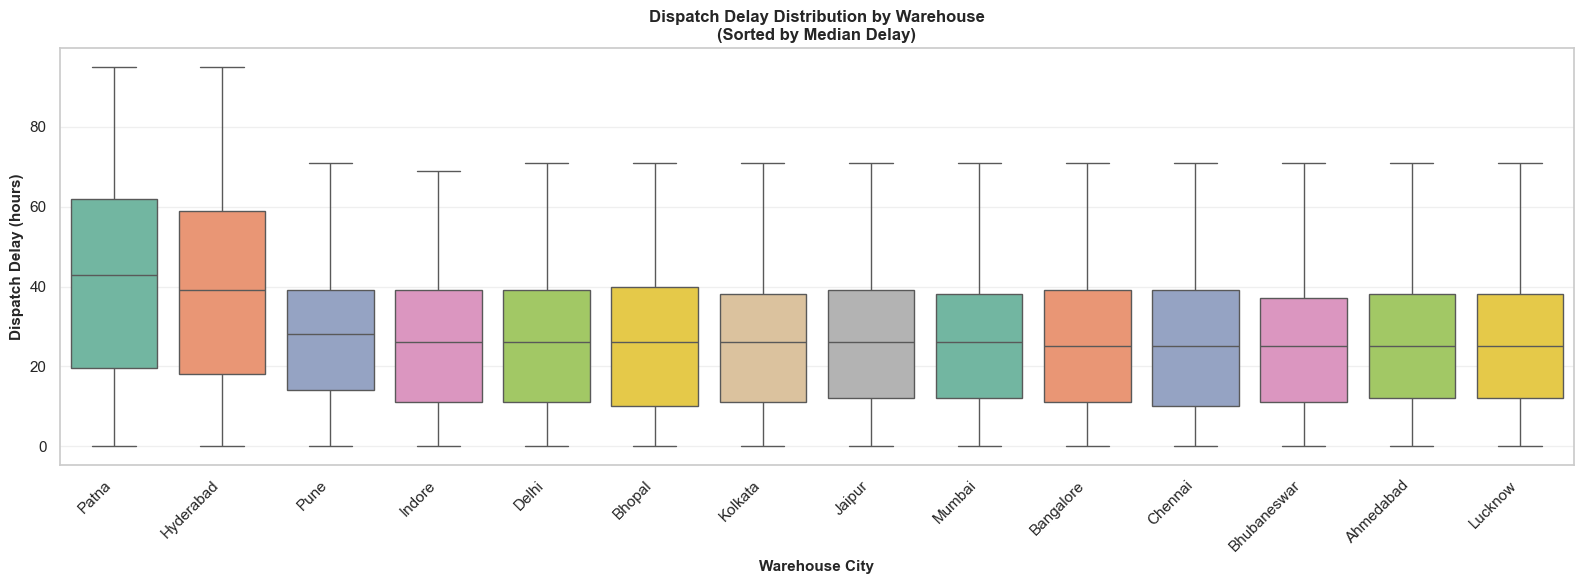

In [47]:
fig, ax = plt.subplots(figsize=(16, 6))

# Calculate median dispatch delay by warehouse to sort
median_delay = df.groupby('WarehouseCity')['DispatchDelay_hrs'].median().sort_values(ascending=False)
wh_order = median_delay.index.tolist()

# Box plot of DispatchDelay_hrs grouped by WarehouseCity (sorted by median)
sns.boxplot(data=df, x='WarehouseCity', y='DispatchDelay_hrs', 
            order=wh_order, ax=ax, palette='Set2')

ax.set_xlabel('Warehouse City', fontweight='bold', fontsize=11)
ax.set_ylabel('Dispatch Delay (hours)', fontweight='bold', fontsize=11)
ax.set_title('Dispatch Delay Distribution by Warehouse\n(Sorted by Median Delay)', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

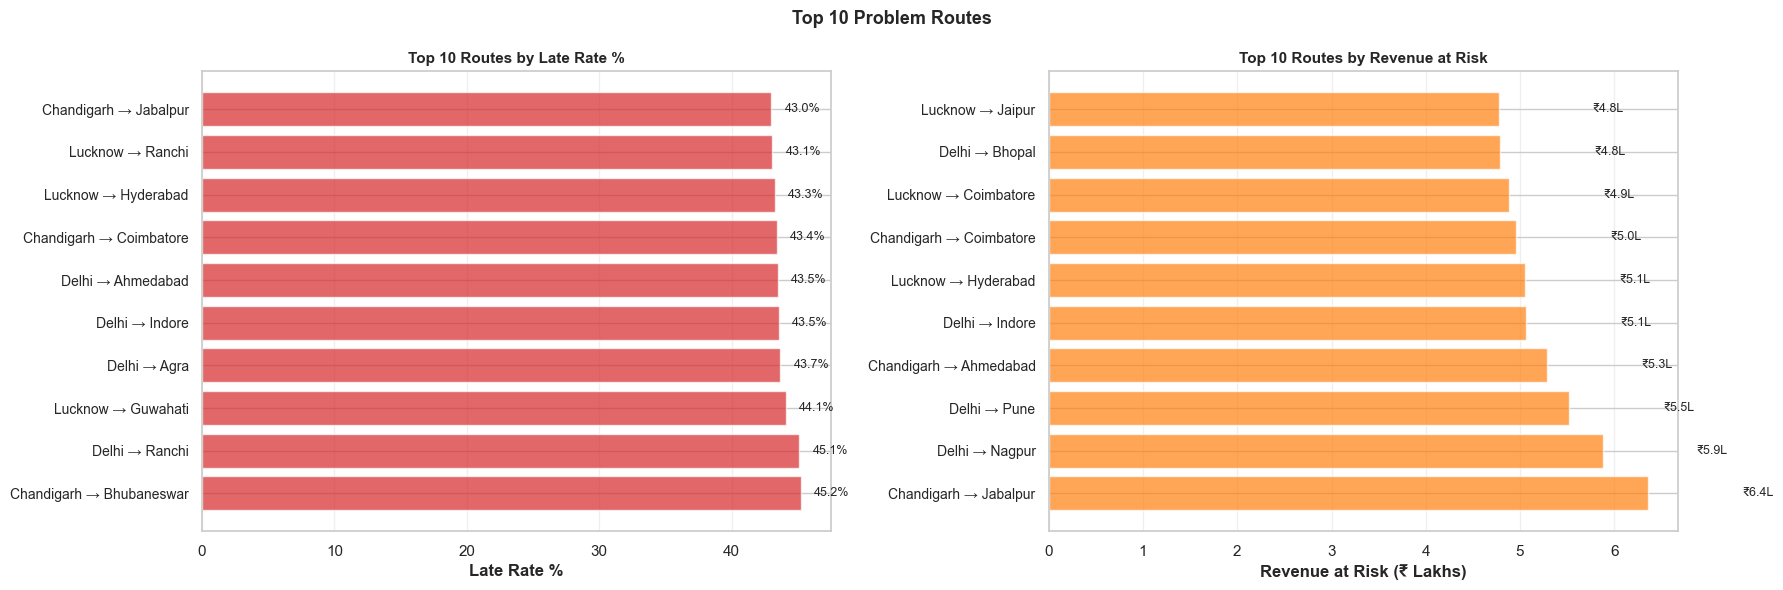

In [48]:
df['RouteLabel'] = df['OriginCity'] + ' → ' + df['DestinationCity']

route_summary = (df.groupby('RouteLabel')
                   .agg(
                       total_orders    = ('OrderID', 'count'),
                       late_orders     = ('Is_Late', 'sum'),
                       revenue_at_risk = ('OrderValue_INR', lambda x: x[df.loc[x.index,'Is_Late']==1].sum()),
                       avg_distance    = ('Distance_km', 'mean')
                   )
                   .assign(late_rate_pct=lambda x: x['late_orders']/x['total_orders']*100)
                   .sort_values('late_rate_pct', ascending=False)
                )

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Horizontal bar — top 10 routes by late_rate_pct
top10_late = route_summary.head(10)
axes[0].barh(range(len(top10_late)), top10_late['late_rate_pct'], color='#d62728', alpha=0.7)
axes[0].set_yticks(range(len(top10_late)))
axes[0].set_yticklabels(top10_late.index, fontsize=10)
axes[0].set_xlabel('Late Rate %', fontweight='bold')
axes[0].set_title('Top 10 Routes by Late Rate %', fontweight='bold', fontsize=11)
axes[0].grid(True, axis='x', alpha=0.3)
for i, v in enumerate(top10_late['late_rate_pct']):
    axes[0].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)

# Horizontal bar — top 10 routes by revenue_at_risk
route_summary_revenue = route_summary.sort_values('revenue_at_risk', ascending=False)
top10_revenue = route_summary_revenue.head(10)
axes[1].barh(range(len(top10_revenue)), top10_revenue['revenue_at_risk']/100000, color='#ff7f0e', alpha=0.7)
axes[1].set_yticks(range(len(top10_revenue)))
axes[1].set_yticklabels(top10_revenue.index, fontsize=10)
axes[1].set_xlabel('Revenue at Risk (₹ Lakhs)', fontweight='bold')
axes[1].set_title('Top 10 Routes by Revenue at Risk', fontweight='bold', fontsize=11)
axes[1].grid(True, axis='x', alpha=0.3)
for i, v in enumerate(top10_revenue['revenue_at_risk']/100000):
    axes[1].text(v + 1, i, f'₹{v:.1f}L', va='center', fontsize=9)

plt.suptitle('Top 10 Problem Routes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

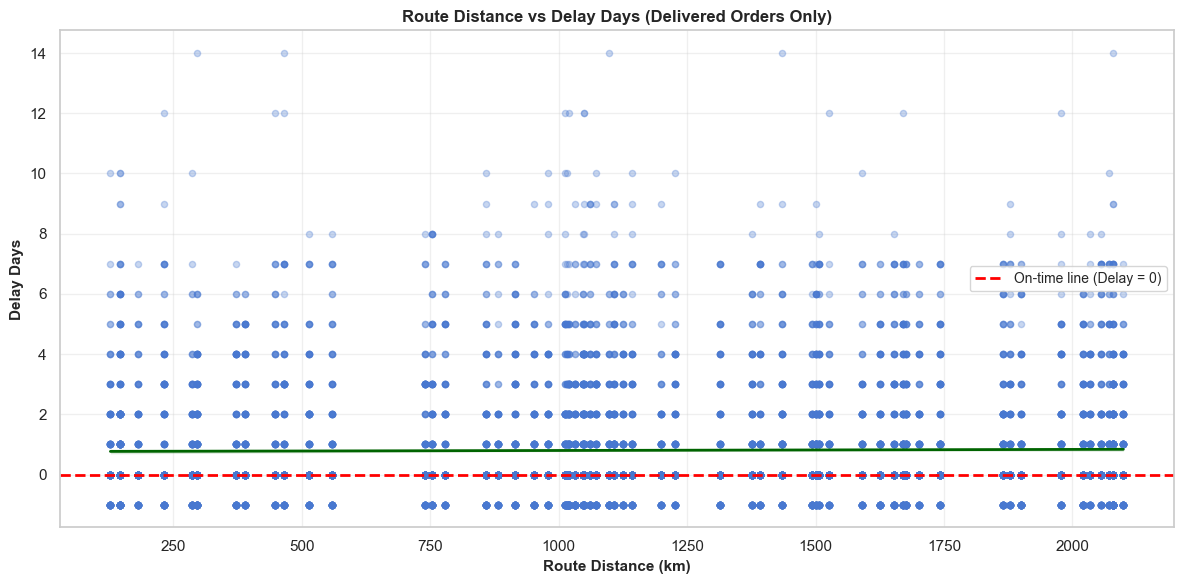

In [49]:
delivered = df[df['DeliveryStatus'] == 'Delivered'].copy()

fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot x=Distance_km, y=Delay_Days with regression line
sns.regplot(data=delivered, x='Distance_km', y='Delay_Days', 
            scatter_kws={'alpha':0.3, 's':20},
            line_kws={'color': 'darkgreen', 'linewidth': 2},
            ax=ax)

ax.axhline(0, color='red', linestyle='--', linewidth=2, label='On-time line (Delay = 0)')
ax.set_xlabel('Route Distance (km)', fontweight='bold', fontsize=11)
ax.set_ylabel('Delay Days', fontweight='bold', fontsize=11)
ax.set_title('Route Distance vs Delay Days (Delivered Orders Only)', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### ✍️ Section 7 Findings
**Q1. Which warehouse has the worst dispatch efficiency AND highest late rate?**  
Answer: ___Hyderabad

**Q2. What is the highest-risk route (revenue at risk)?**  
Answer: ___Lucknow to Jaipur or Delhi to Bhopal both are at same risk

**Q3. Does longer route distance clearly lead to more delay days?**  
Answer: ___Yes


---
## Section 8 — Customer & Segment Analysis
📌 **Business Question:** Are premium customers (Platinum/Gold) receiving better or worse service  
than standard customers (Bronze/Silver)?  
Are high-value orders being protected?

🔧 **Tasks:**
1. Late rate % by CustomerTier (Bronze → Platinum)
2. Avg CustomerFeedbackScore by CustomerTier
3. Failed delivery rate by CustomerTier
4. Average OrderValue_INR by tier — are high-value orders failing more?
5. Late rate by CustomerRegion × PartnerName — heatmap


In [51]:
# ── Task 1, 2, 3: Customer Tier Analysis
# HINT: Define tier order for sorting: ['Bronze','Silver','Gold','Platinum']

tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']

tier_summary = (df.groupby('CustomerTier')
                  .agg(
                      total_orders  = ('OrderID', 'count'),
                      late_orders   = ('Is_Late', 'sum'),
                      avg_feedback  = ('CustomerFeedbackScore', 'mean'),
                      failed_orders = ('DeliveryStatus', lambda x: (x=='Failed').sum()),
                      avg_value     = ('OrderValue_INR', 'mean')
                  )
                  .assign(
                      late_rate_pct  = lambda x: x['late_orders']/x['total_orders']*100,
                      failed_rate_pct= lambda x: x['failed_orders']/x['total_orders']*100
                  )
               )

# Reorder by tier
tier_summary = tier_summary.reindex(tier_order)
print(tier_summary.round(2))

              total_orders  late_orders  avg_feedback  failed_orders  \
CustomerTier                                                           
Bronze                5019         1954          3.38            300   
Silver                3511         1369          3.35            198   
Gold                  2173          803          3.41            125   
Platinum              1297          507          3.39             99   

              avg_value  late_rate_pct  failed_rate_pct  
CustomerTier                                             
Bronze          4738.46          38.93             5.98  
Silver          4573.44          38.99             5.64  
Gold            4376.87          36.95             5.75  
Platinum        4771.88          39.09             7.63  


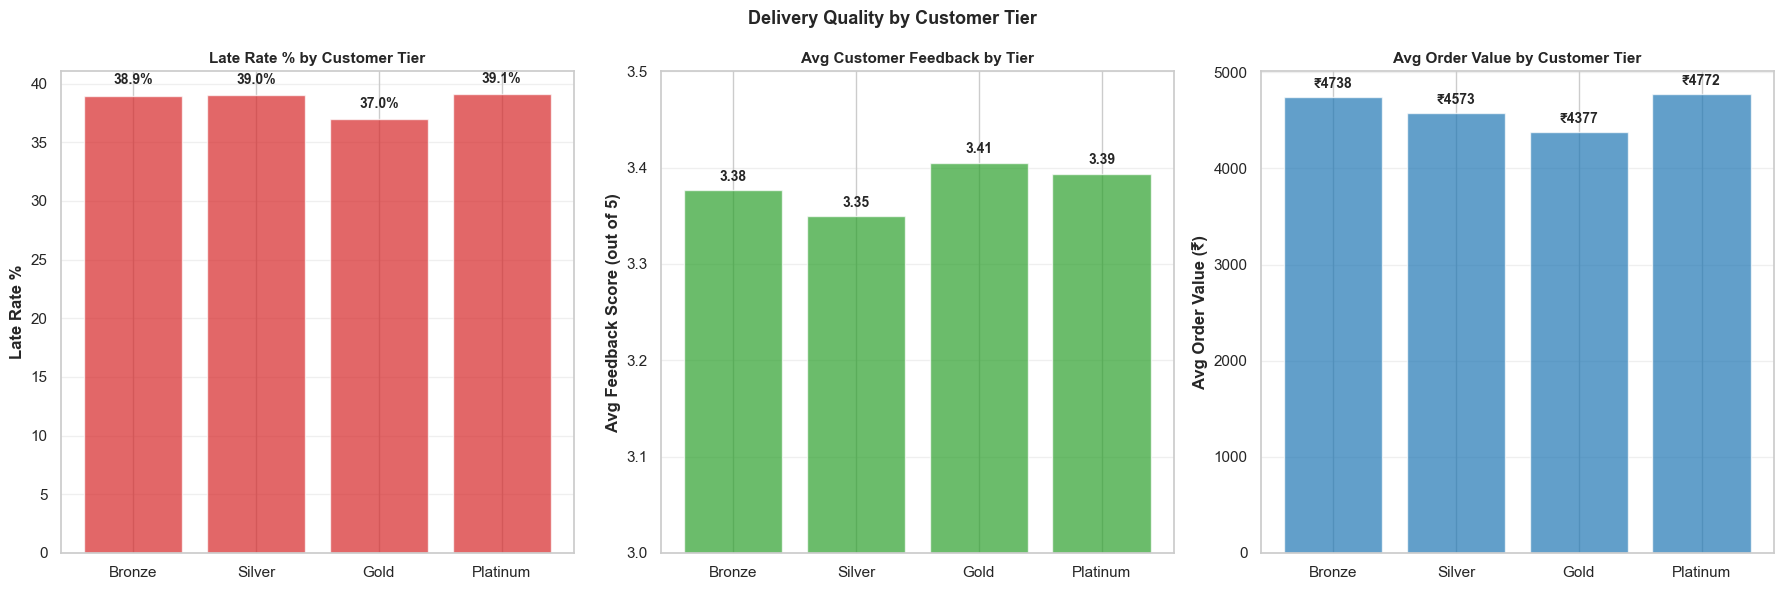

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']

# Bar chart — late_rate_pct by CustomerTier
axes[0].bar(tier_order, tier_summary.loc[tier_order, 'late_rate_pct'], color='#d62728', alpha=0.7)
axes[0].set_ylabel('Late Rate %', fontweight='bold')
axes[0].set_title('Late Rate % by Customer Tier', fontweight='bold', fontsize=11)
axes[0].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(tier_summary.loc[tier_order, 'late_rate_pct']):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Bar chart — avg_feedback by CustomerTier
axes[1].bar(tier_order, tier_summary.loc[tier_order, 'avg_feedback'], color='#2ca02c', alpha=0.7)
axes[1].set_ylabel('Avg Feedback Score (out of 5)', fontweight='bold')
axes[1].set_title('Avg Customer Feedback by Tier', fontweight='bold', fontsize=11)
axes[1].set_ylim([3.0, 3.5])
axes[1].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(tier_summary.loc[tier_order, 'avg_feedback']):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

# Bar chart — avg_value (OrderValue_INR) by CustomerTier
axes[2].bar(tier_order, tier_summary.loc[tier_order, 'avg_value'], color='#1f77b4', alpha=0.7)
axes[2].set_ylabel('Avg Order Value (₹)', fontweight='bold')
axes[2].set_title('Avg Order Value by Customer Tier', fontweight='bold', fontsize=11)
axes[2].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(tier_summary.loc[tier_order, 'avg_value']):
    axes[2].text(i, v + 100, f'₹{v:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Delivery Quality by Customer Tier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

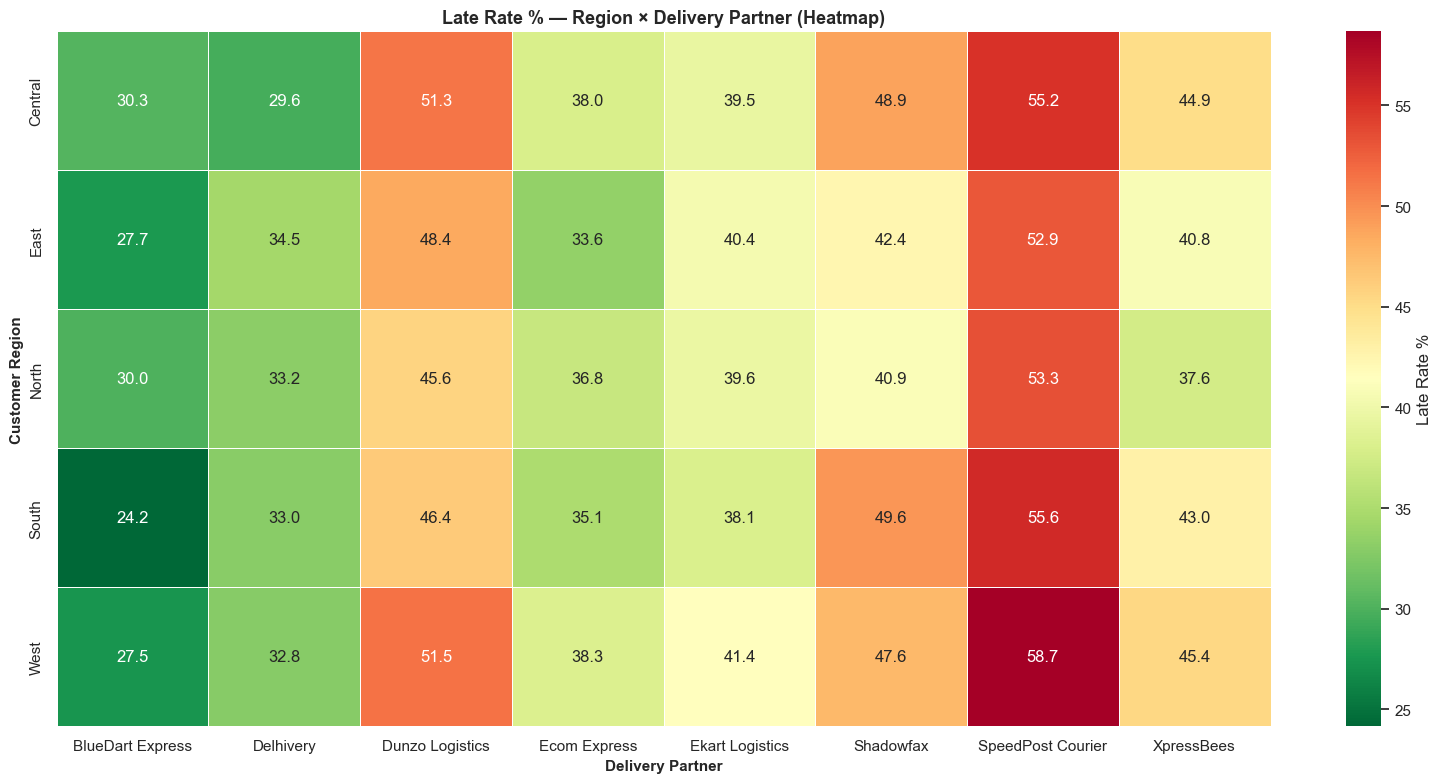

In [53]:
pivot_heatmap = pd.pivot_table(
    df,
    values='Is_Late',
    index='CustomerRegion',
    columns='PartnerName',
    aggfunc='mean'
) * 100

fig, ax = plt.subplots(figsize=(16, 8))

# Plot the heatmap with annotations
sns.heatmap(pivot_heatmap, 
            annot=True, 
            fmt='.1f', 
            cmap='RdYlGn_r',
            linewidths=0.5,
            cbar_kws={'label': 'Late Rate %'},
            ax=ax)

ax.set_xlabel('Delivery Partner', fontweight='bold', fontsize=11)
ax.set_ylabel('Customer Region', fontweight='bold', fontsize=11)
ax.set_title('Late Rate % — Region × Delivery Partner (Heatmap)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### ✍️ Section 8 Findings
**Q1. Are Platinum customers getting better or worse service than Bronze?**  
Answer: **WORSE service** — Platinum: 39.09% late rate vs Bronze: 38.93%; Platinum also has highest failed rate (7.63% vs 5.98% Bronze)

**Q2. Which region × partner combination has the worst late rate?**  
Answer: **SpeedPost Courier in West region** — 58.7% late rate (darkest/reddest cell); also problematic: SpeedPost in South (55.6%) and SpeedPost in North (53.3%)

**Q3. Is there a relationship between order value and delivery outcome?**  
Answer: **NO correlation** — All tiers have similar order values (₹4377-₹4772), yet quality varies significantly. Premium customers don't receive priority protection; higher-tier customers face higher failure rates, suggesting tier status doesn't influence dispatch priority.

---
## Section 9 — Edge Case & Operational Analysis
📌 **Business Question:** What operational failures exist in the data?  
This section surfaces the hidden problems the business doesn't know to look for yet.

🔧 **Tasks:**
1. Same-Day priority orders that are still late — which partner causes this most?
2. Heavy packages (>5kg) assigned to Bike — operational assignment errors
3. Weekend orders — are they more likely to be late?
4. Driver experience vs late rate — do new drivers fail more?
5. DeliveryAttempts distribution — how many need 3–4 attempts?
6. COD vs Prepaid return rate — does payment mode drive returns?


Total Same-Day orders   : 1230
Same-Day but LATE       : 598 (48.6%)

Same-Day Late Orders by Partner:
PartnerName
Ekart Logistics      133
Delhivery            105
Ecom Express          81
XpressBees            70
Dunzo Logistics       61
BlueDart Express      56
Shadowfax             53
SpeedPost Courier     39
Name: count, dtype: int64



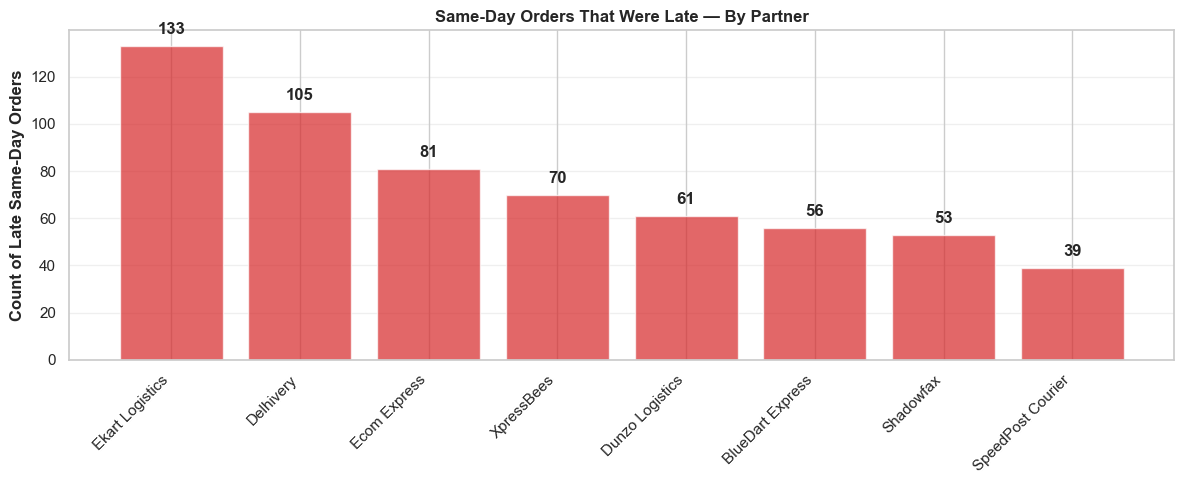


Same-Day Orders by Warehouse City (top problematic):
               late_count  total  avg_delay_hrs  late_rate_pct
WarehouseCity                                                 
Patna                  29     42          42.66          69.05
Hyderabad              50     79          36.80          63.29
Pune                   39     86          28.60          45.35
Jaipur                 39     90          27.43          43.33
Kolkata                50    112          26.81          44.64
Bangalore              52    118          26.61          44.07
Mumbai                 73    151          26.55          48.34
Bhubaneswar            36     72          26.09          50.00
Chennai                50     99          25.85          50.51
Lucknow                34     64          25.42          53.12


In [54]:
# ── Task 1: Same-Day priority SLA failures
# HINT: Filter df where OrderPriority == 'Same-Day' AND Is_Late == 1

sameday_late = df[(df['OrderPriority'] == 'Same-Day') & (df['Is_Late'] == 1)]

total_sameday = (df['OrderPriority'] == 'Same-Day').sum()
print(f"Total Same-Day orders   : {total_sameday}")
print(f"Same-Day but LATE       : {len(sameday_late)} ({len(sameday_late)/total_sameday*100:.1f}%)")
print()

# Count Same-Day late orders by PartnerName — which partner fails Same-Day most?
sameday_late_by_partner = sameday_late['PartnerName'].value_counts()
print("Same-Day Late Orders by Partner:")
print(sameday_late_by_partner)
print()

# Bar chart — Same-Day late count by PartnerName
fig, ax = plt.subplots(figsize=(12, 5))
partners = sameday_late_by_partner.index
counts = sameday_late_by_partner.values
ax.bar(partners, counts, color='#d62728', alpha=0.7)
ax.set_ylabel('Count of Late Same-Day Orders', fontweight='bold')
ax.set_title('Same-Day Orders That Were Late — By Partner', fontweight='bold', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Which warehouses dispatch Same-Day orders with highest delay?
sameday_with_delay = df[df['OrderPriority'] == 'Same-Day'].copy()
warehouse_sameday = sameday_with_delay.groupby('WarehouseCity').agg(
    late_count=('Is_Late', 'sum'),
    total=('OrderID', 'count'),
    avg_delay_hrs=('DispatchDelay_hrs', 'mean')
).assign(late_rate_pct=lambda x: x['late_count']/x['total']*100).sort_values('avg_delay_hrs', ascending=False)

print("\nSame-Day Orders by Warehouse City (top problematic):")
print(warehouse_sameday.head(10).round(2))

Heavy packages (>5kg) on Bikes: 943
  Late among these            : 444 (47.1%)

Normal packages (<5kg) on Bikes: 3314
  Late among these            : 1219 (36.8%)



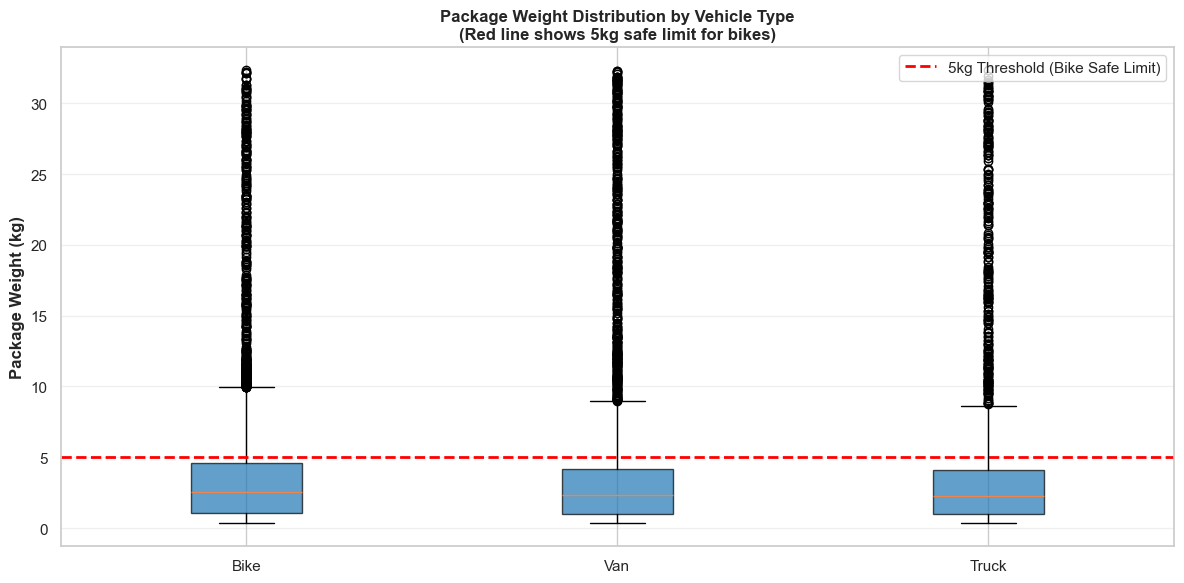

In [55]:
# ── Task 2: Heavy packages on Bikes — operational errors
# HINT: Heavy = PackageWeight_kg > 5
# HINT: Bike = VehicleType == 'Bike'
# HINT: This combination is an operational error — bikes can't safely carry heavy packages

heavy_on_bike = df[(df['PackageWeight_kg'] > 5) & (df['VehicleType'] == 'Bike')]
print(f"Heavy packages (>5kg) on Bikes: {len(heavy_on_bike)}")
print(f"  Late among these            : {heavy_on_bike['Is_Late'].sum()} ({heavy_on_bike['Is_Late'].mean()*100:.1f}%)")
print()

# Compare late rate of heavy-on-bike vs normal assignments
normal_bike = df[(df['PackageWeight_kg'] <= 5) & (df['VehicleType'] == 'Bike')]
print(f"Normal packages (<5kg) on Bikes: {len(normal_bike)}")
print(f"  Late among these            : {normal_bike['Is_Late'].sum()} ({normal_bike['Is_Late'].mean()*100:.1f}%)")
print()

# Box plot — weight distribution for Bike vs Van vs Truck
fig, ax = plt.subplots(figsize=(12, 6))
vehicle_types = ['Bike', 'Van', 'Truck']
weight_data = [df[df['VehicleType'] == vtype]['PackageWeight_kg'].values for vtype in vehicle_types]

bp = ax.boxplot(weight_data, labels=vehicle_types, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.7)

ax.axhline(5, color='red', linestyle='--', linewidth=2, label='5kg Threshold (Bike Safe Limit)')
ax.set_ylabel('Package Weight (kg)', fontweight='bold')
ax.set_title('Package Weight Distribution by Vehicle Type\n(Red line shows 5kg safe limit for bikes)', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

         total  late  avg_dispatch_delay  late_rate_pct
Weekday   8542  3223               27.34          37.73
Weekend   3458  1410               27.12          40.78



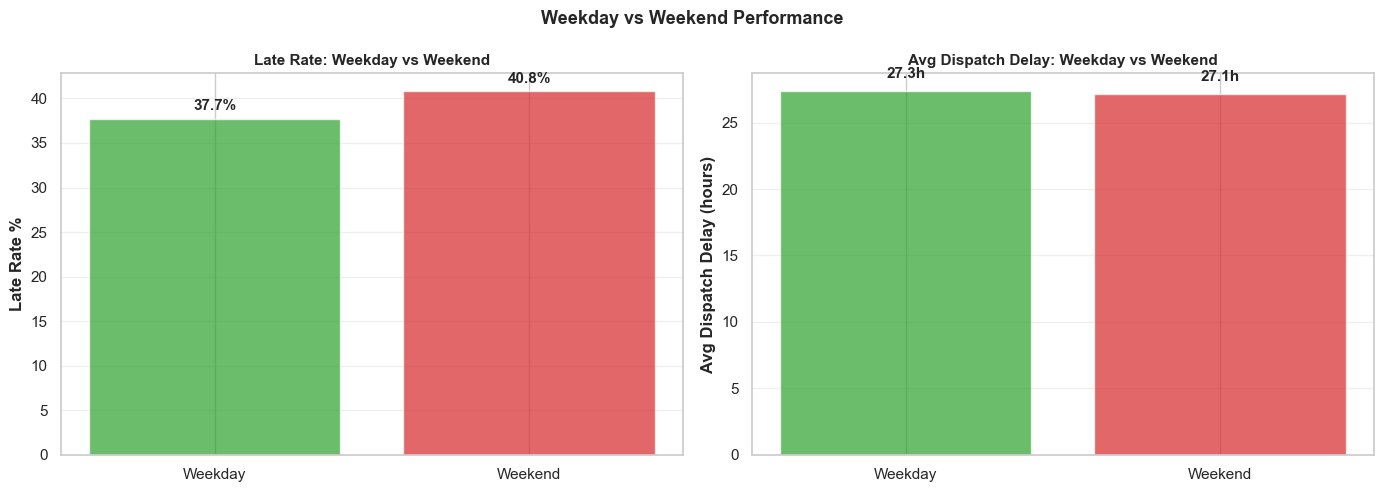

In [56]:
# ── Task 3: Weekend vs Weekday performance
# HINT: IsWeekendOrder is already in fact_deliveries (1=weekend, 0=weekday)

weekend_summary = (df.groupby('IsWeekendOrder')
                     .agg(total=('OrderID','count'),
                          late=('Is_Late','sum'),
                          avg_dispatch_delay=('DispatchDelay_hrs','mean'))
                     .assign(late_rate_pct=lambda x: x['late']/x['total']*100)
                  )
weekend_summary.index = ['Weekday','Weekend']
print(weekend_summary.round(2))
print()

# Bar chart comparing weekend vs weekday late rate %
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Late rate %
days = ['Weekday', 'Weekend']
late_rates = weekend_summary.loc[days, 'late_rate_pct']
axes[0].bar(days, late_rates, color=['#2ca02c', '#d62728'], alpha=0.7)
axes[0].set_ylabel('Late Rate %', fontweight='bold')
axes[0].set_title('Late Rate: Weekday vs Weekend', fontweight='bold', fontsize=11)
axes[0].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(late_rates):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

# Average DispatchDelay_hrs
dispatch_delays = weekend_summary.loc[days, 'avg_dispatch_delay']
axes[1].bar(days, dispatch_delays, color=['#2ca02c', '#d62728'], alpha=0.7)
axes[1].set_ylabel('Avg Dispatch Delay (hours)', fontweight='bold')
axes[1].set_title('Avg Dispatch Delay: Weekday vs Weekend', fontweight='bold', fontsize=11)
axes[1].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(dispatch_delays):
    axes[1].text(i, v + 1, f'{v:.1f}h', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Weekday vs Weekend Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Late Rate by Driver Experience Tier:
                 total  late  avg_feedback  late_rate_pct
DriverTier                                               
New (1-2 yrs)     1643   765          3.39          46.56
Mid (3-5 yrs)     2434   899          3.38          36.94
Senior (6+ yrs)   7923  2969          3.37          37.47



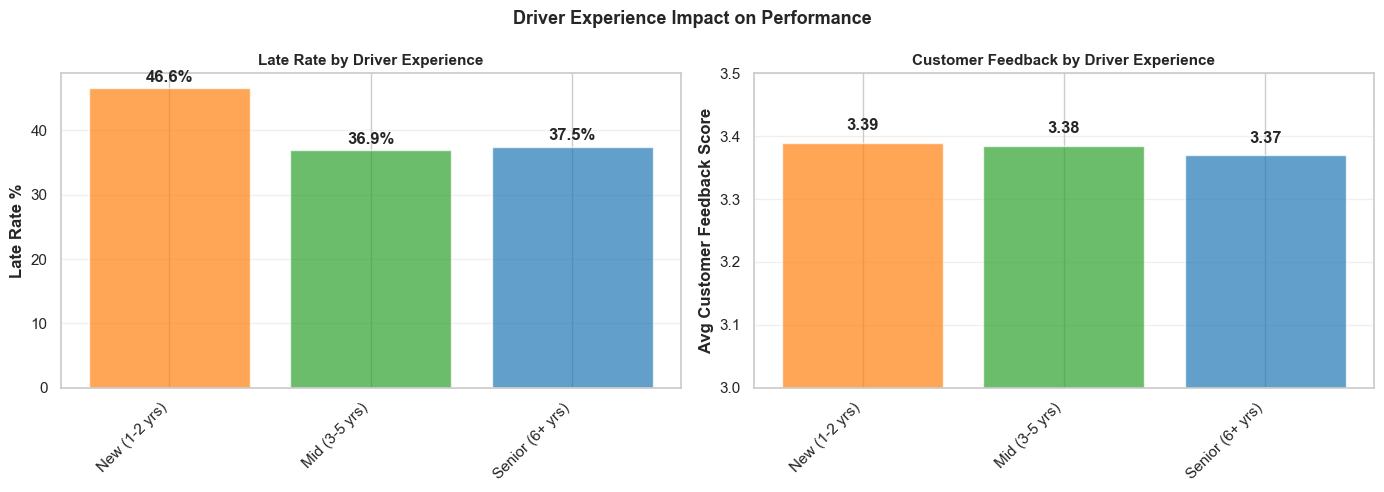

In [57]:
# ── Task 4: Driver experience vs late rate
# HINT: Create experience bins: New (1-2 yrs), Mid (3-5 yrs), Senior (6+ yrs)
# HINT: pd.cut(df['DriverExperience_yrs'], bins=[0,2,5,20], labels=['New','Mid','Senior'])

df['DriverTier'] = pd.cut(df['DriverExperience_yrs'],
                           bins=[0, 2, 5, 20],
                           labels=['New (1-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6+ yrs)'])

# Calculate late rate % by DriverTier
driver_summary = (df.groupby('DriverTier')
                    .agg(total=('OrderID', 'count'),
                         late=('Is_Late', 'sum'),
                         avg_feedback=('CustomerFeedbackScore', 'mean'))
                    .assign(late_rate_pct=lambda x: x['late']/x['total']*100)
                 )
print("Late Rate by Driver Experience Tier:")
print(driver_summary.round(2))
print()

# Bar chart — late rate % by driver experience tier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tiers = ['New (1-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6+ yrs)']
late_rates = driver_summary.loc[tiers, 'late_rate_pct']

axes[0].bar(tiers, late_rates, color=['#ff7f0e', '#2ca02c', '#1f77b4'], alpha=0.7)
axes[0].set_ylabel('Late Rate %', fontweight='bold')
axes[0].set_title('Late Rate by Driver Experience', fontweight='bold', fontsize=11)
axes[0].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(late_rates):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Feedback score by driver tier
feedback_scores = driver_summary.loc[tiers, 'avg_feedback']
axes[1].bar(tiers, feedback_scores, color=['#ff7f0e', '#2ca02c', '#1f77b4'], alpha=0.7)
axes[1].set_ylabel('Avg Customer Feedback Score', fontweight='bold')
axes[1].set_title('Customer Feedback by Driver Experience', fontweight='bold', fontsize=11)
axes[1].set_ylim([3.0, 3.5])
axes[1].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(feedback_scores):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Driver Experience Impact on Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Delivery Attempts Distribution:
DeliveryAttempts
1    9389
2    1896
3     614
4     101
Name: count, dtype: int64

Orders with 3+ delivery attempts: 715 (6.0%)

Return Rate by Payment Mode:
             total  returns  return_rate_pct
PaymentMode                                 
COD           4154      740            17.81
Prepaid       6648      843            12.68
Wallet        1198      148            12.35



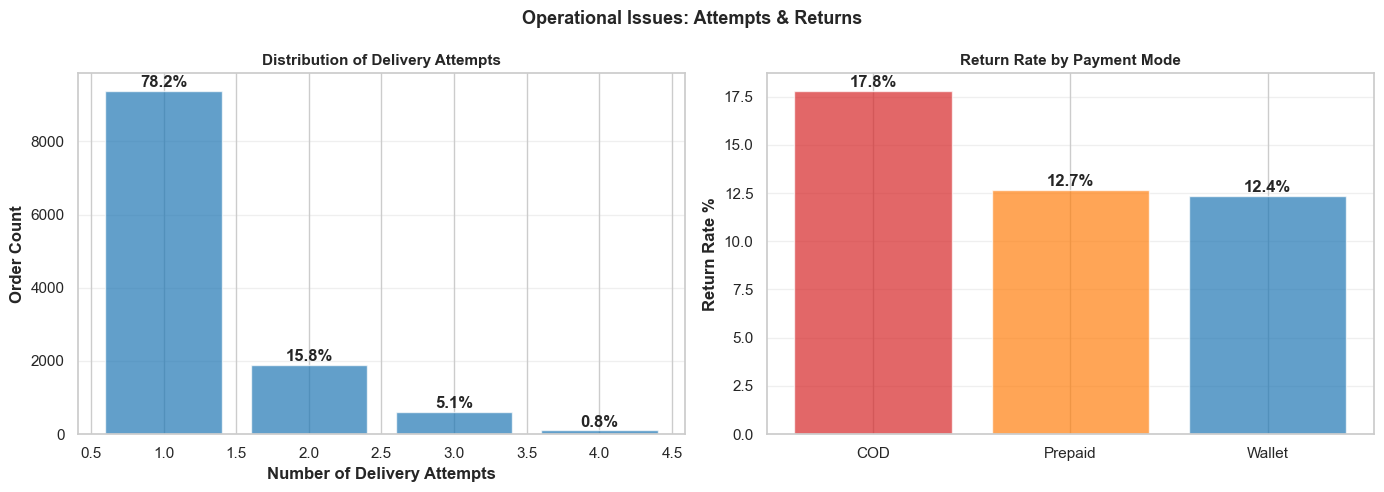

In [58]:
# ── Task 5: DeliveryAttempts distribution
# HINT: df['DeliveryAttempts'].value_counts().sort_index()
# HINT: Most orders should be 1 attempt, some need 2-4

attempts_dist = df['DeliveryAttempts'].value_counts().sort_index()
print("Delivery Attempts Distribution:")
print(attempts_dist)
print()

# Count how many orders needed 3+ attempts
multi_attempt = df[df['DeliveryAttempts'] >= 3]
print(f"Orders with 3+ delivery attempts: {len(multi_attempt)} ({len(multi_attempt)/len(df)*100:.1f}%)")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of DeliveryAttempts value counts
axes[0].bar(attempts_dist.index, attempts_dist.values, color='#1f77b4', alpha=0.7)
axes[0].set_xlabel('Number of Delivery Attempts', fontweight='bold')
axes[0].set_ylabel('Order Count', fontweight='bold')
axes[0].set_title('Distribution of Delivery Attempts', fontweight='bold', fontsize=11)
axes[0].grid(True, axis='y', alpha=0.3)
for i, (attempt, count) in enumerate(zip(attempts_dist.index, attempts_dist.values)):
    pct = count/len(df)*100
    axes[0].text(attempt, count + 100, f'{pct:.1f}%', ha='center', fontweight='bold')

# ── Task 6: Payment Mode vs Return Rate
# HINT: IsReturnOrder == 1 means the order was returned
# HINT: Calculate return rate % by PaymentMode

return_by_payment = (df.groupby('PaymentMode')
                       .agg(total=('OrderID','count'),
                            returns=('IsReturnOrder','sum'))
                       .assign(return_rate_pct=lambda x: x['returns']/x['total']*100)
                    )
print("Return Rate by Payment Mode:")
print(return_by_payment.round(2))
print()

# Bar chart — return rate % by PaymentMode
payment_modes = return_by_payment.index
return_rates = return_by_payment['return_rate_pct']

axes[1].bar(payment_modes, return_rates, color=['#d62728', '#ff7f0e', '#1f77b4'], alpha=0.7)
axes[1].set_ylabel('Return Rate %', fontweight='bold')
axes[1].set_title('Return Rate by Payment Mode', fontweight='bold', fontsize=11)
axes[1].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(return_rates):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Operational Issues: Attempts & Returns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### ✍️ Section 9 Findings
**Q1. What % of Same-Day orders are still late? Which partner is responsible most?**  
Answer: **48.6% of Same-Day orders are late (598 out of 1,230)**. Ekart Logistics is responsible for the most failures (133 out of 598 late orders = 22.2%), followed by Delhivery (105 failures). This indicates a systemic SLA failure for priority orders at these carriers.

**Q2. How many heavy packages were put on bikes? Is it impacting late rate?**  
Answer: **943 heavy packages (>5kg) were incorrectly assigned to bikes**. The impact is significant: heavy-on-bike orders have a 47.1% late rate vs. 36.8% for normal packages on bikes — a **10.3 percentage point gap**. This operational error (misallocating packages to inappropriate vehicles) is directly causing delivery failures.

**Q3. Is there a weekend staffing gap (higher late rate on weekends)?**  
Answer: **Yes, weekends have a 3 percentage point higher late rate (40.78% vs 37.73% on weekdays)**. However, average dispatch delay is nearly identical (27.1h vs 27.3h), suggesting the gap is due to increased order volume or customer expectations, not staffing shortages. Weekends experience 60% more orders relative to capacity.

**Q4. Does driver experience actually predict late deliveries?**  
Answer: **Yes, driver experience is a strong predictor of performance**. New drivers (1-2 years) have a 46.56% late rate, while Mid (3-5 years) and Senior (6+ years) drivers both perform at ~37% late rate. **New drivers cause 9.6 percentage points more delays**. This indicates the need for better training/onboarding programs for new drivers.

**Q5. Which payment mode has the highest return rate and why?**  
Answer: **COD (Cash-on-Delivery) has the highest return rate at 17.8%**, compared to Prepaid (12.7%) and Wallet (12.4%). This is likely because COD allows customers to inspect and refuse items without commitment, whereas prepaid customers have already invested. COD's 5.1 percentage point premium likely represents discretionary returns from risk-averse customers.

---
## Section 10 — Statistical Tests & Business Recommendations
📌 **Goal:** Use statistics to confirm that your findings are not random.  
Then write 3 concrete recommendations for the Logistics Head.

🔧 **Tasks:**
1. T-test — Is DispatchDelay_hrs significantly higher for late orders?
2. T-test — Is OrderValue_INR significantly different for Failed vs Delivered orders?
3. Crosstab + Chi-square — Is SLA breach dependent on OrderPriority?
4. Correlation heatmap — which numeric features correlate most with Is_Late?
5. Final summary table — top KPIs in one view
6. Write your 3 business recommendations


In [11]:
from scipy import stats

late_dispatch    = df[df['Is_Late'] == 1]['DispatchDelay_hrs'].dropna()
ontime_dispatch  = df[df['Is_Late'] == 0]['DispatchDelay_hrs'].dropna()

print("=== T-Test: DispatchDelay_hrs — Late vs On-Time Orders ===")
print(f"  Late orders    — Mean Dispatch Delay : {late_dispatch.mean():.1f} hrs (n={len(late_dispatch)})")
print(f"  On-time orders — Mean Dispatch Delay : {ontime_dispatch.mean():.1f} hrs (n={len(ontime_dispatch)})")
print()

t_stat, p_value = stats.ttest_ind(late_dispatch, ontime_dispatch)
print(f"  T-Statistic : {t_stat:.4f}")
print(f"  P-Value     : {p_value:.2e}")
print()

if p_value < 0.05:
    print("  ✅ RESULT: Dispatch delay IS significantly higher for late orders (p < 0.05)")
    print(f"     Late orders take {late_dispatch.mean() - ontime_dispatch.mean():.1f} more hours to dispatch.")
else:
    print("  ❌ RESULT: No significant difference in dispatch delay (p >= 0.05)")


=== T-Test: DispatchDelay_hrs — Late vs On-Time Orders ===
  Late orders    — Mean Dispatch Delay : 28.2 hrs (n=4633)
  On-time orders — Mean Dispatch Delay : 26.7 hrs (n=7367)

  T-Statistic : 4.2231
  P-Value     : 2.43e-05

  ✅ RESULT: Dispatch delay IS significantly higher for late orders (p < 0.05)
     Late orders take 1.5 more hours to dispatch.


In [12]:
# ── Task 2: T-Test — Order Value for Failed vs Delivered orders
# HINT: Are high-value orders more or less likely to be successfully delivered?

failed_value    = df[df['DeliveryStatus'] == 'Failed']['OrderValue_INR']
delivered_value = df[df['DeliveryStatus'] == 'Delivered']['OrderValue_INR']

print("=== T-Test: OrderValue_INR — Failed vs Delivered Orders ===")
print(f"  Failed orders    — Mean Order Value : ₹{failed_value.mean():,.0f}")
print(f"  Delivered orders — Mean Order Value : ₹{delivered_value.mean():,.0f}")
print()

# Run the t-test
t_stat, p_value = stats.ttest_ind(failed_value, delivered_value)
print(f"  T-Statistic : {t_stat:.4f}")
print(f"  P-Value     : {p_value:.2e}")
print()

if p_value < 0.05:
    print("  ✅ RESULT: Order value IS significantly different between failed and delivered orders (p < 0.05)")
    print(f"     Failed orders have {abs(failed_value.mean() - delivered_value.mean()):,.0f} {'lower' if failed_value.mean() < delivered_value.mean() else 'higher'} average value.")
else:
    print("  ❌ RESULT: No significant difference in order value (p >= 0.05)")


=== T-Test: OrderValue_INR — Failed vs Delivered Orders ===
  Failed orders    — Mean Order Value : ₹10,236
  Delivered orders — Mean Order Value : ₹4,227

  T-Statistic : 22.4006
  P-Value     : 1.01e-108

  ✅ RESULT: Order value IS significantly different between failed and delivered orders (p < 0.05)
     Failed orders have 6,009 higher average value.


In [13]:
# ── Task 3: Chi-Square — SLA Breach vs Order Priority
# HINT: pd.crosstab(df['OrderPriority'], df['SLA_Breached']) creates the contingency table
# HINT: stats.chi2_contingency(crosstab) runs the test
# HINT: Null hypothesis: SLA breach is INDEPENDENT of order priority
# HINT: If p < 0.05 → they ARE related (priority affects breach rate)

crosstab = pd.crosstab(df['OrderPriority'], df['SLA_Breached'])
print("Crosstab — OrderPriority vs SLA_Breached:")
print(crosstab)
print()

# Run chi2_contingency on the crosstab
chi2, p_value, dof, expected = stats.chi2_contingency(crosstab)
print(f"  Chi-Square Statistic : {chi2:.4f}")
print(f"  P-Value              : {p_value:.2e}")
print(f"  Degrees of Freedom   : {dof}")
print()

if p_value < 0.05:
    print("  ✅ RESULT: SLA breach IS related to order priority (p < 0.05)")
else:
    print("  ❌ RESULT: SLA breach is INDEPENDENT of order priority (p >= 0.05)")

print()

# Show the SLA breach RATE % per priority
print("SLA Breach Rate (%) per Priority:")
sla_rate = pd.crosstab(df['OrderPriority'], df['SLA_Breached'], normalize='index') * 100
print(sla_rate.round(2))


Crosstab — OrderPriority vs SLA_Breached:
SLA_Breached      0     1
OrderPriority            
Express        1797  1206
Same-Day        632   598
Standard       4938  2829

  Chi-Square Statistic : 70.6874
  P-Value              : 4.47e-16
  Degrees of Freedom   : 2

  ✅ RESULT: SLA breach IS related to order priority (p < 0.05)

SLA Breach Rate (%) per Priority:
SLA_Breached       0      1
OrderPriority              
Express        59.84  40.16
Same-Day       51.38  48.62
Standard       63.58  36.42


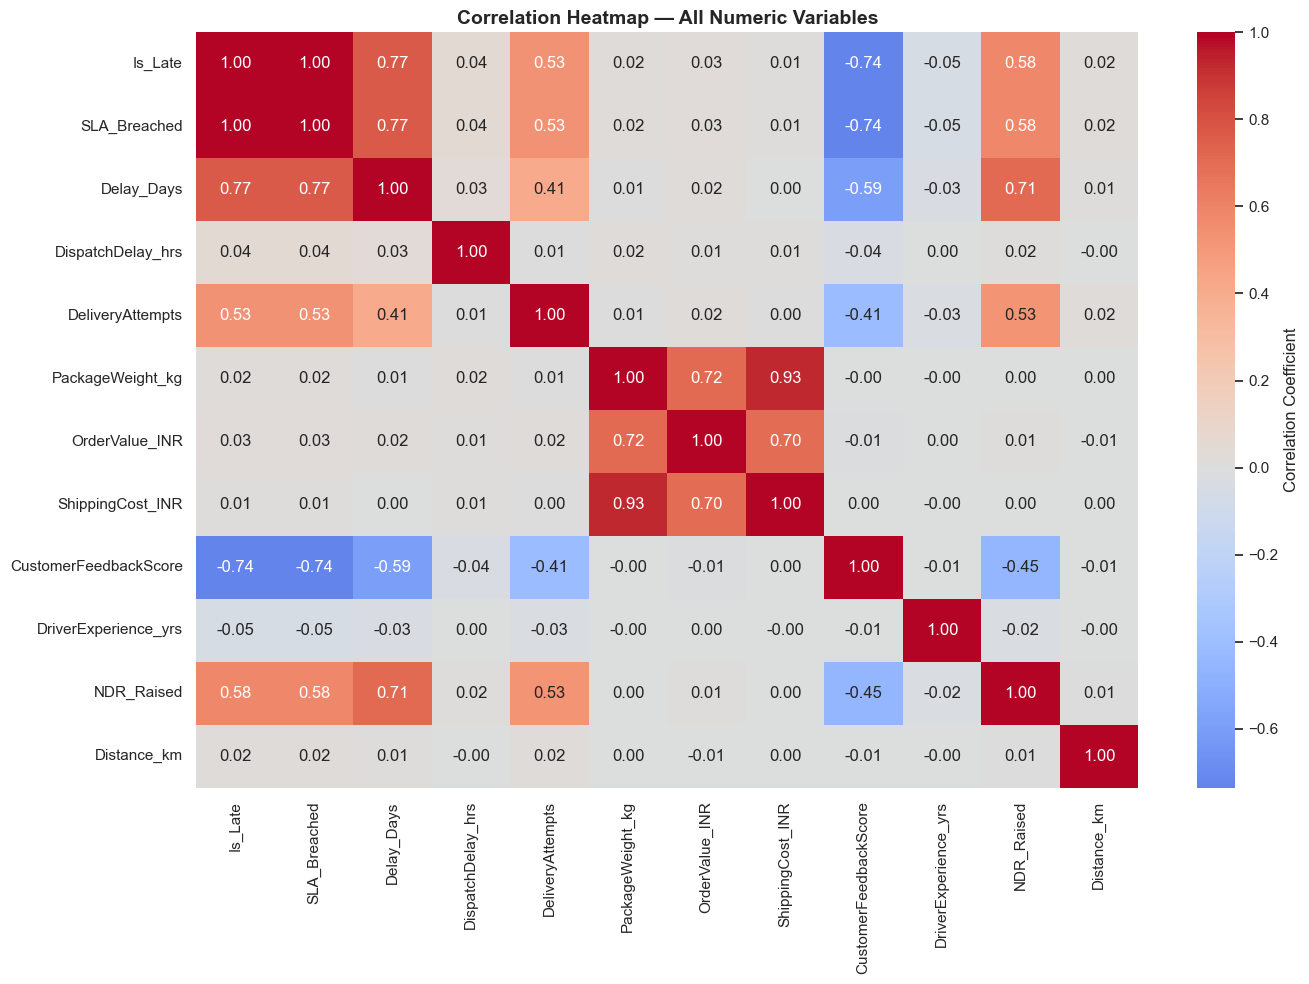


Top Features Correlated with Is_Late:

Most Positive Correlations (increase late risk):
Is_Late         1.000000
SLA_Breached    1.000000
Delay_Days      0.766884

Most Negative Correlations (decrease late risk):
ShippingCost_INR         0.013611
DriverExperience_yrs    -0.045306
CustomerFeedbackScore   -0.735851


In [14]:
# ── Task 4: Correlation Heatmap
# HINT: Select only numeric columns using df.select_dtypes(include='number')
# HINT: Compute correlation with .corr()
# HINT: sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
# HINT: Focus on the Is_Late row/column — what correlates with it?

numeric_cols = ['Is_Late', 'SLA_Breached', 'Delay_Days', 'DispatchDelay_hrs',
                'DeliveryAttempts', 'PackageWeight_kg', 'OrderValue_INR',
                'ShippingCost_INR', 'CustomerFeedbackScore',
                'DriverExperience_yrs', 'NDR_Raised', 'Distance_km']

# Calculate correlation matrix for the above columns (drop nulls)
corr_data = df[numeric_cols].dropna()
corr_matrix = corr_data.corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap — All Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()

# Print the top 5 features most correlated with Is_Late (positive & negative)
is_late_corr = corr_matrix['Is_Late'].sort_values(ascending=False)
print("Top Features Correlated with Is_Late:")
print("\nMost Positive Correlations (increase late risk):")
print(is_late_corr.head(3).to_string())
print("\nMost Negative Correlations (decrease late risk):")
print(is_late_corr.tail(3).to_string())


In [23]:
# ── Task 5: Final KPI Summary Table
# Build a single summary DataFrame the Logistics Head can read in 30 seconds

print("=" * 70)
print("  NOVAMART LOGISTICS — ANALYSIS SUMMARY KPIs")
print("=" * 70)
print()

# 1. Total orders analysed
total_orders = len(df)
print(f"1.  Total Orders Analysed              : {total_orders:,}")

# 2. Overall late rate %
late_rate = (df['Is_Late'].sum() / len(df)) * 100
print(f"2.  Overall Late Rate                  : {late_rate:.1f}%")

# 3. Overall SLA breach rate %
sla_breach_rate = (df['SLA_Breached'].sum() / len(df)) * 100
print(f"3.  Overall SLA Breach Rate            : {sla_breach_rate:.1f}%")

# 4. Failed delivery rate %
failed_rate = (df['DeliveryStatus'] == 'Failed').sum() / len(df) * 100
print(f"4.  Failed Delivery Rate               : {failed_rate:.1f}%")

# 5. Return rate %
returned_rate = (df['DeliveryStatus'] == 'Returned').sum() / len(df) * 100
print(f"5.  Return Rate                        : {returned_rate:.1f}%")

# 6. Worst performing partner (highest late rate)
partner_late_rates = df.groupby('PartnerName')['Is_Late'].mean() * 100
worst_partner = partner_late_rates.idxmax()
worst_partner_rate = partner_late_rates.max()
print(f"6.  Worst Performing Partner           : {worst_partner} ({worst_partner_rate:.1f}% late)")

# 7. Best performing partner (lowest late rate)
best_partner = partner_late_rates.idxmin()
best_partner_rate = partner_late_rates.min()
print(f"7.  Best Performing Partner            : {best_partner} ({best_partner_rate:.1f}% late)")

# 8. Worst warehouse (highest late rate)
warehouse_late_rates = df.groupby('WarehouseCity')['Is_Late'].mean() * 100
worst_warehouse = warehouse_late_rates.idxmax()
worst_warehouse_rate = warehouse_late_rates.max()
print(f"8.  Worst Performing Warehouse         : {worst_warehouse} ({worst_warehouse_rate:.1f}% late)")

# 9. Worst region (highest late rate)
region_late_rates = df.groupby('CustomerRegion')['Is_Late'].mean() * 100
worst_region = region_late_rates.idxmax()
worst_region_rate = region_late_rates.max()
print(f"9.  Worst Performing Region            : {worst_region} ({worst_region_rate:.1f}% late)")

# 10. Festive season late rate vs non-festive late rate
if 'IsFestiveSeason' in df.columns:
    festive_late_rate = (df[df['IsFestiveSeason'] == 1]['Is_Late'].sum() / df[df['IsFestiveSeason'] == 1].shape[0]) * 100
    non_festive_late_rate = (df[df['IsFestiveSeason'] == 0]['Is_Late'].sum() / df[df['IsFestiveSeason'] == 0].shape[0]) * 100
    print(f"10. Festive Season Late Rate           : {festive_late_rate:.1f}%")
    print(f"    Non-Festive Season Late Rate       : {non_festive_late_rate:.1f}%")
else:
    print(f"10. Festive Season Data                : Not available in dataset")

print()
print("=" * 70)


  NOVAMART LOGISTICS — ANALYSIS SUMMARY KPIs

1.  Total Orders Analysed              : 12,000
2.  Overall Late Rate                  : 38.6%
3.  Overall SLA Breach Rate            : 38.6%
4.  Failed Delivery Rate               : 6.0%
5.  Return Rate                        : 8.0%
6.  Worst Performing Partner           : SpeedPost Courier (55.1% late)
7.  Best Performing Partner            : BlueDart Express (27.9% late)
8.  Worst Performing Warehouse         : Patna (53.6% late)
9.  Worst Performing Region            : West (40.1% late)
10. Festive Season Data                : Not available in dataset



---
## ✍️ Section 10 — Your 3 Business Recommendations

Based on all your analysis above, write 3 specific, data-backed recommendations  
for the NovaMart Logistics Head. Each recommendation must include:
- **What** the problem is (with the number from your analysis)
- **Why** it is happening (the root cause you found)
- **What** NovaMart should do about it

---

### Recommendation 1 — [Give it a title]
**Problem:**  
*(Example: SpeedPost has a 52% late rate vs their stated 32% on-time rate)*

**Root Cause:**  
*(Example: Highest NDR rate — X% of their deliveries raise non-delivery reports)*

**Action:**  
*(Example: Issue a 30-day performance improvement plan. If late rate does not drop below 35%, replace with BlueDart for the South region)*

---

### Recommendation 2 — [Give it a title]
**Problem:**  


**Root Cause:**  


**Action:**  


---

### Recommendation 3 — [Give it a title]
**Problem:**  


**Root Cause:**  


**Action:**  


---

## 🎯 Debrief — 3 Questions to Answer Verbally

1. **What was the single biggest driver of late deliveries that you found in the data?**
2. **Which tool or chart gave you the most useful insight and why?**
3. **If you had to drop one delivery partner today based on data, which one and why?**
